<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 09 - Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Explainability (XAI)

A pricing actuary asks why the model quotes 1,200 € to a 21-year-old. A regulator asks which factors drive the premiums of a whole portfolio. A data scientist asks whether the model learned something stupid, like a policy number. All three questions are about **explaining a model**, and they need different tools: *global* explanations describe the model as a whole, *local* explanations describe one prediction.

In real data we never know the right answer, so we cannot tell a good explanation from a plausible-looking wrong one. This lab therefore works on a **fictional motor-insurance portfolio that we simulate ourselves**: we know the true expected cost of every policy, including an interaction and two pairs of correlated features. Every method is built **from scratch**, checked against scikit-learn where a reference exists, and graded against the truth.

**Contents**

1. A fictional portfolio with a known truth
2. Interpretable by design, and three black boxes
3. Feature importance: impurity versus permutation
4. Partial dependence and ICE curves
5. ALE plots and a global surrogate tree
6. Shapley values, exactly
7. KernelSHAP and the SHAP plots
8. LIME and its instability
9. Neural networks: saliency, Integrated Gradients, Grad-CAM and a sanity check
10. Counterfactual explanations and a fairness check
11. Summary and exercises

This lab goes with the slides *Extra 9 · Explainability* and uses the same notation. It assumes linear regression, decision trees, random forests, gradient boosting and CNNs from the course. The libraries `shap` and `lime` are not needed: we write the methods ourselves. The whole notebook runs on a CPU in about 1.5 minutes with 4 threads (3 to 4 minutes on a free Colab CPU); a GPU is not needed.

**Notation**

| Symbol | Meaning |
|---|---|
| $f$, $f(\mathbf{x})$ | the trained model and its prediction for one policy (euros per year) |
| $\mathbf{x} = (x_1, \dots, x_M)$ | one policy with $M$ features; $\mathbf{X}$ the data matrix, one row per policy |
| $\mu(\mathbf{x})$ | the true expected cost, known here because the data are simulated |
| $S \subseteq \{1, \dots, M\}$, $\mathbf{x}_S$, $\mathbf{x}_{\bar S}$ | a coalition (subset) of features, its values, and the values of the other features |
| $\mathrm{PD}_j(z)$, $\mathrm{ALE}_j(z)$ | partial dependence and accumulated local effect of feature $j$ at the value $z$ |
| $v(S)$ | value of a coalition: the expected prediction when only $\mathbf{x}_S$ is known |
| $\phi_j$, $\phi_0 = v(\varnothing)$ | Shapley (SHAP) value of feature $j$; baseline = average prediction |
| $\pi_{\mathbf{x}}(\mathbf{z}) = e^{-\lVert\mathbf{z} - \mathbf{x}\rVert^2/\sigma^2}$ | LIME proximity kernel of width $\sigma$ (distances in standard deviations) |
| $\nabla_{\mathbf{x}} f$, $\mathbf{x}'$, $\mathrm{IG}_j$ | gradient of the output with respect to the input (saliency), baseline input, integrated gradient of input $j$ |
| $\mathbf{x}^{\mathrm{cf}}$, $\tau$ | counterfactual policy, decision threshold (refer to underwriting if $f(\mathbf{x}) \gt \tau$) |

In [1]:
import math, time, itertools, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import partial_dependence, permutation_importance
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| numpy", np.__version__)
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | numpy 2.3.3


## 1. A fictional portfolio with a known truth

We simulate 6,000 motor policies of a **fictional** insurer. Each policy has $M = 9$ features:

| feature | meaning | how it is drawn | true effect on the expected cost |
|---|---|---|---|
| `age` | driver age (years) | uniform 18–80 | young drivers: $250\,e^{-(\text{age}-18)/6}$; over 60: $+5$ €/year |
| `licence_years` | years since the driving licence | age − 18 − uniform(0, 10), at least 0 | novices: $300\,e^{-\text{licence}/2}$ |
| `power` | engine power (kW) | 50 + gamma, men +15 kW on average | $1.8$ €/kW above 100 kW, **plus 4 €/kW for drivers under 25** |
| `car_value` | value of the car (k€) | $0.22\cdot$power + noise | **none** |
| `mileage` | thousand km per year | gamma, mean 14 | $8$ € per 1,000 km |
| `urban` | lives in a city (0/1) | 45 % urban | $+120$ € |
| `vehicle_age` | age of the car (years) | uniform 0–19 | **none** |
| `deductible` | chosen deductible (€) | 0, 250, 500 or 1,000 | $-0.15$ € per € of deductible |
| `prior_claims` | claims in the last 3 years | Poisson(0.25) | $+90$ € per claim |

The true expected annual cost is

$$\mu(\mathbf{x}) = 400 + 300\,e^{-\text{lic}/2} + 250\,e^{-(\text{age}-18)/6} + 5\,(\text{age}-60)_+ + 1.8\,(\text{power}-100) + 4\,(\text{power}-100)_+\,\mathbb{1}[\text{age}\lt 25] + 8\,(\text{km}-14) + 120\,\text{urban} - 0.15\,\text{ded} + 90\,\text{claims},$$

and the observed cost is $y = \mu(\mathbf{x}) + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 120^2)$. Real claim costs are mostly zeros with a heavy tail; we keep Gaussian noise so that every explanation can be compared with a clean truth. The design contains the traps of real portfolios:

- `age` and `licence_years` are **strongly correlated** and **both** matter (youth and inexperience);
- `car_value` is correlated with `power` but has **no effect** of its own, and `vehicle_age` has no effect at all;
- `power` **interacts** with age: a powerful car is much riskier in the hands of a driver under 25;
- the sex of the driver is simulated but is **not a model input** (EU insurers may not price on sex since 2012). Men drive more powerful cars in this portfolio, which matters in section 10.

In [2]:
FEATS = ["age", "licence_years", "power", "car_value", "mileage", "urban", "vehicle_age", "deductible", "prior_claims"]
M = len(FEATS)
J = {name: j for j, name in enumerate(FEATS)}           # column index of each feature

def make_portfolio(n, seed):
    """Simulate n fictional policies. Returns the feature matrix and the sex of the driver (not a feature)."""
    rng = np.random.default_rng(seed)
    age = rng.uniform(18, 80, n)
    licence = np.maximum(0, age - 18 - rng.uniform(0, 10, n))
    male = rng.random(n) < 0.5
    power = np.clip(50 + rng.gamma(2, 22, n) + 15 * male, 45, 250)
    car_value = np.clip(0.22 * power + rng.normal(0, 4, n), 4, 80)
    mileage = np.clip(rng.gamma(4, 3.5, n), 2, 50)
    urban = (rng.random(n) < 0.45).astype(float)
    vehicle_age = rng.integers(0, 20, n).astype(float)
    deductible = rng.choice([0., 250., 500., 1000.], n, p=[0.3, 0.3, 0.25, 0.15])
    prior = np.minimum(rng.poisson(0.25, n), 4).astype(float)
    X = np.column_stack([age, licence, power, car_value, mileage, urban, vehicle_age, deductible, prior])
    return X, male

def true_cost(X):
    """mu(x): the true expected annual claim cost in euros."""
    age, lic, power, car_value, km, urban, vage, ded, prior = X.T
    return (400 + 300 * np.exp(-lic / 2) + 250 * np.exp(-(age - 18) / 6) + 5 * np.maximum(0, age - 60)
            + 1.8 * (power - 100) + 4 * np.maximum(0, power - 100) * (age < 25)
            + 8 * (km - 14) + 120 * urban - 0.15 * ded + 90 * prior)

X_all, male_all = make_portfolio(6000, seed=0)
mu_all = true_cost(X_all)
y_all = mu_all + np.random.default_rng(1).normal(0, 120, len(X_all))
X_tr, X_te, y_tr, y_te = X_all[:4000], X_all[4000:], y_all[:4000], y_all[4000:]
mu_tr, mu_te, male_te = mu_all[:4000], mu_all[4000:], male_all[4000:]

# the policy we will explain again and again: a 21-year-old with a powerful car
policy_A = np.array([21, 2, 160, 35, 22, 1, 8, 0, 1.])

print(f"train {X_tr.shape}, test {X_te.shape}")
print(f"observed cost: mean {y_all.mean():.0f} €, std {y_all.std():.0f} €;  true cost mu: std {mu_all.std():.0f} €")
print(f"correlation age–licence_years: {np.corrcoef(X_all[:, 0], X_all[:, 1])[0, 1]:.3f}")
print(f"correlation power–car_value:   {np.corrcoef(X_all[:, 2], X_all[:, 3])[0, 1]:.3f}")
print(f"mean power: men {X_all[male_all, 2].mean():.1f} kW, women {X_all[~male_all, 2].mean():.1f} kW")
print(f"R² of the TRUTH on the test set: {r2_score(y_te, mu_te):.3f}   (no model can beat it on average)")
print(f"policy A: mu = {true_cost(policy_A[None])[0]:.0f} €")

train (4000, 9), test (2000, 9)
observed cost: mean 507 €, std 226 €;  true cost mu: std 194 €
correlation age–licence_years: 0.987
correlation power–car_value:   0.863
mean power: men 108.7 kW, women 94.3 kW
R² of the TRUTH on the test set: 0.721   (no model can beat it on average)
policy A: mu = 1284 €


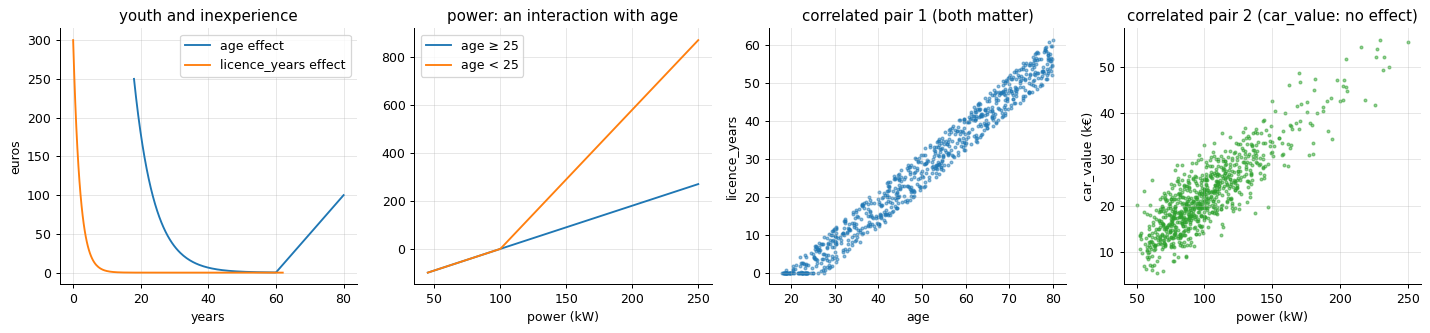

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
a = np.linspace(18, 80, 200)
axes[0].plot(a, 250 * np.exp(-(a - 18) / 6) + 5 * np.maximum(0, a - 60), label="age effect")
axes[0].plot(a - 18, 300 * np.exp(-(a - 18) / 2), label="licence_years effect")
axes[0].set_xlabel("years"); axes[0].set_ylabel("euros"); axes[0].set_title("youth and inexperience"); axes[0].legend()
p = np.linspace(45, 250, 200)
axes[1].plot(p, 1.8 * (p - 100), label="age ≥ 25")
axes[1].plot(p, 1.8 * (p - 100) + 4 * np.maximum(0, p - 100), label="age < 25")
axes[1].set_xlabel("power (kW)"); axes[1].set_title("power: an interaction with age"); axes[1].legend()
axes[2].scatter(X_tr[:800, 0], X_tr[:800, 1], s=5, alpha=0.5)
axes[2].set_xlabel("age"); axes[2].set_ylabel("licence_years"); axes[2].set_title("correlated pair 1 (both matter)")
axes[3].scatter(X_tr[:800, 2], X_tr[:800, 3], s=5, alpha=0.5, color="tab:green")
axes[3].set_xlabel("power (kW)"); axes[3].set_ylabel("car_value (k€)"); axes[3].set_title("correlated pair 2 (car_value: no effect)")
plt.tight_layout(); plt.show()

**Things to notice.**
- The two correlated pairs are tight: $\rho = 0.987$ between `age` and `licence_years`, $\rho = 0.863$ between `power` and `car_value`. In the data, a 25-year-old with 30 years of licence never occurs.
- Men drive 108.7 kW on average and women 94.3 kW: sex is not a feature, but `power` partly reveals it.
- The truth itself reaches only $R^2 = 0.721$ on the test set: the noise ($\sigma = 120$ €, against a standard deviation of 226 € for the observed cost) sets a ceiling that no model can beat on average.
- Policy A, a 21-year-old with 2 years of licence, a 160 kW car, 22,000 km a year in a city and one past claim, has a true expected cost of 1,284 €, two and a half times the average of 507 €.

## 2. Interpretable by design, and three black boxes

Before explaining a black box, try a model that explains itself.

- **Linear regression** $f(\mathbf{x}) = \beta_0 + \sum_j \beta_j x_j$: $\beta_j$ is the change in prediction per unit of $x_j$, *all other features fixed*. With correlated features "all other fixed" is a situation the data rarely show, and the coefficients become unstable.
- **Generalised additive model (GAM)** $f(\mathbf{x}) = \beta_0 + \sum_j g_j(x_j)$: each $g_j$ is a free curve, here a cubic spline (`SplineTransformer` + ridge regression). The model *is* its plot: one curve per feature. It cannot represent interactions unless we add them explicitly.
- **Small decision trees**: a handful of if–then rules (section 5 uses one as a surrogate).

The black boxes are a **random forest** and **gradient boosting** (`HistGradientBoostingRegressor`). We score every model by the test $R^2$ against the noisy cost and by its RMSE against the true cost $\mu$, which only a simulation lets us measure.

In [4]:
spline_cols = [J[c] for c in ["age", "licence_years", "power", "car_value", "mileage", "vehicle_age"]]
linear_cols = [J[c] for c in ["urban", "deductible", "prior_claims"]]
lin = LinearRegression()
gam = make_pipeline(ColumnTransformer([("spline", SplineTransformer(n_knots=8, degree=3), spline_cols),
                                       ("linear", "passthrough", linear_cols)]),
                    RidgeCV(alphas=np.logspace(-3, 3, 13)))
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=0)
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=20, random_state=0)
models = {"linear regression": lin, "GAM (splines)": gam, "random forest": rf, "gradient boosting": hgb}

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

print(f"{'model':20s} {'test R²':>8s} {'RMSE to truth mu (€)':>22s}")
for name, model in models.items():
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    print(f"{name:20s} {r2_score(y_te, pred):8.3f} {rmse(pred, mu_te):22.1f}")
print(f"{'the truth mu':20s} {r2_score(y_te, mu_te):8.3f} {0:22.1f}")

boot = np.array([LinearRegression().fit(X_tr[i], y_tr[i]).coef_
                 for i in np.random.default_rng(0).integers(0, len(X_tr), (50, len(X_tr)))])
print("\nlinear coefficients (euros per unit) and their spread over 50 bootstrap refits:")
for j, name in enumerate(FEATS):
    print(f"  {name:14s} {lin.coef_[j]:8.2f}   ± {boot[:, j].std():.2f}")

model                 test R²   RMSE to truth mu (€)
linear regression       0.385                  126.4
GAM (splines)           0.698                   32.5


random forest           0.666                   53.2


gradient boosting       0.698                   38.0
the truth mu            0.721                    0.0

linear coefficients (euros per unit) and their spread over 50 bootstrap refits:
  age               -9.45   ± 0.94
  licence_years      5.51   ± 0.89
  power              2.09   ± 0.19
  car_value          0.16   ± 0.61
  mileage            7.92   ± 0.44
  urban            115.78   ± 6.88
  vehicle_age       -0.29   ± 0.48
  deductible        -0.15   ± 0.01
  prior_claims      86.80   ± 5.28


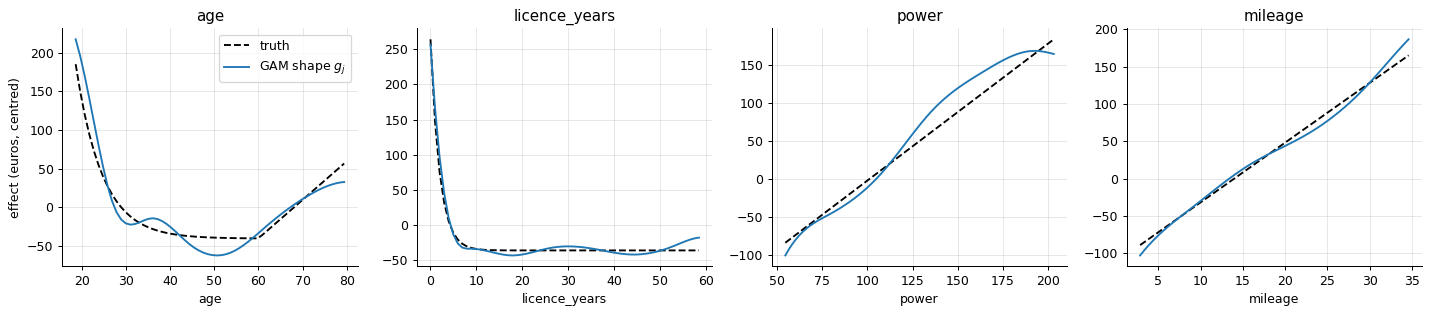

In [5]:
TRUE_PART = {"age": lambda a: 250 * np.exp(-(a - 18) / 6) + 5 * np.maximum(0, a - 60),
             "licence_years": lambda l: 300 * np.exp(-l / 2),
             "power": lambda p: 1.8 * (p - 100),            # for drivers aged 25 or more
             "mileage": lambda k: 8 * (k - 14)}

def gam_shape(j, grid):
    """Shape function g_j of the GAM: vary feature j, keep the others at their mean (the model is additive)."""
    Z = np.tile(X_tr.mean(0), (len(grid), 1)); Z[:, j] = grid
    return gam.predict(Z)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, name in zip(axes, TRUE_PART):
    j = J[name]; grid = np.linspace(*np.percentile(X_tr[:, j], [1, 99]), 60)
    g, t = gam_shape(j, grid), TRUE_PART[name](grid)
    centre = lambda c: c - np.interp(X_tr[:, j], grid, c).mean()     # mean effect over the data = 0
    ax.plot(grid, centre(t), "k--", label="truth")
    ax.plot(grid, centre(g), color="tab:blue", label="GAM shape $g_j$")
    ax.set_xlabel(name); ax.set_title(name)
axes[0].set_ylabel("effect (euros, centred)"); axes[0].legend()
plt.tight_layout(); plt.show()

**What just happened?**
- The **linear model** cannot bend: $R^2 = 0.385$, 126 € away from the truth on average. Its coefficients for the correlated pair are $-9.45 \pm 0.94$ for `age` and $+5.51 \pm 0.89$ for `licence_years`: a *positive* effect of experience, the opposite of the truth. "One more year of licence, same age" never happens in the data ($\rho = 0.987$), so the model is free to trade one coefficient against the other. Where there is no collinearity the coefficients are right: deductible $-0.15$ (truth $-0.15$), mileage 7.92 (truth 8), urban 115.8 (truth 120), prior claims 86.8 (truth 90), and `car_value` $0.16 \pm 0.61$, zero within its noise.
- The **GAM** is the best model of the four: $R^2 = 0.698$ and only 32.5 € from the truth, better than gradient boosting (38.0 €) and the random forest (53.2 €). Its shape functions follow the true curves. The truth is additive except for one interaction that concerns few policies, so a model that is interpretable by design loses nothing here. Always try one before reaching for a black box (Rudin, 2019).
- From now on we explain the **gradient-boosting** model ($R^2 = 0.698$) as if we did not know the truth, and use the truth to grade the explanations.

## 3. Feature importance: impurity versus permutation

**Impurity importance** (mean decrease in impurity, MDI) is what `feature_importances_` returns for scikit-learn trees and forests: for every split on feature $j$, add the decrease in squared error (weighted by the number of samples at the node), sum over all trees and normalise to 1. It is free, but it is computed **on the training data**: a feature with many possible split points can be used to fit the noise, and gets credit for it. A unique identifier is the extreme case.

**Permutation importance** (Breiman, 2001) measures how much the model *needs* a feature on **held-out data**:

1. compute the test error $e_0$ of the fitted model;
2. for feature $j$: shuffle column $j$ of the test set (this breaks its link with $y$ and with the other features), recompute the error $e_j$; repeat $R$ times;
3. importance$_j$ = mean of $e_j - e_0$.

No refitting is needed. Here the error is the RMSE, so the importance is in euros: "without this feature the predictions are X € worse".

In [6]:
policy_id = np.random.default_rng(2).permutation(len(X_all)).astype(float)   # a random, unique ID per policy
FEATS_ID = FEATS + ["policy_id"]
Xid_tr = np.column_stack([X_tr, policy_id[:4000]]); Xid_te = np.column_stack([X_te, policy_id[4000:]])
rf_id = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=0).fit(Xid_tr, y_tr)   # fully grown trees

def perm_importance(predict, X, y, n_repeats=10, seed=0):
    """Permutation importance from scratch: increase of the RMSE when one column is shuffled."""
    rng = np.random.default_rng(seed)
    base = rmse(y, predict(X))
    imp = np.zeros((X.shape[1], n_repeats))
    for j in range(X.shape[1]):
        for r in range(n_repeats):
            Xp = X.copy(); Xp[:, j] = rng.permutation(Xp[:, j])
            imp[j, r] = rmse(y, predict(Xp)) - base
    return base, imp

base_id, imp_id = perm_importance(rf_id.predict, Xid_te, y_te)
sk = permutation_importance(rf_id, Xid_te, y_te, scoring="neg_root_mean_squared_error", n_repeats=10, random_state=0)
print(f"test RMSE of the forest with the ID column: {base_id:.1f} €")
print(f"{'feature':14s} {'impurity (train)':>16s} {'permutation, ours':>18s} {'sklearn':>9s}")
for j, name in enumerate(FEATS_ID):
    print(f"{name:14s} {rf_id.feature_importances_[j]:16.3f} {imp_id[j].mean():15.1f} €  {sk.importances_mean[j]:6.1f} €")
diff = np.abs(imp_id.mean(1) - sk.importances_mean)
print(f"largest gap ours vs sklearn: {diff.max():.2f} €  (different random shuffles; std of one estimate ≈ {imp_id.std(1).max():.2f} €)")
assert np.all(diff <= 0.1 * np.abs(sk.importances_mean) + 1.0)
rank_mdi = np.argsort(-rf_id.feature_importances_)
print("impurity ranking:", [FEATS_ID[k] for k in rank_mdi])

test RMSE of the forest with the ID column: 131.1 €
feature        impurity (train)  permutation, ours   sklearn
age                       0.069            17.7 €    18.0 €
licence_years             0.408            72.9 €    73.3 €
power                     0.148            28.2 €    28.9 €
car_value                 0.052             0.6 €     0.6 €
mileage                   0.107            19.4 €    19.7 €
urban                     0.061            20.9 €    21.6 €
vehicle_age               0.032            -0.1 €     0.1 €
deductible                0.049            10.8 €    10.9 €
prior_claims              0.032             9.1 €     9.2 €
policy_id                 0.043            -0.1 €    -0.2 €
largest gap ours vs sklearn: 0.71 €  (different random shuffles; std of one estimate ≈ 2.60 €)


impurity ranking: ['licence_years', 'power', 'mileage', 'age', 'urban', 'car_value', 'deductible', 'policy_id', 'vehicle_age', 'prior_claims']


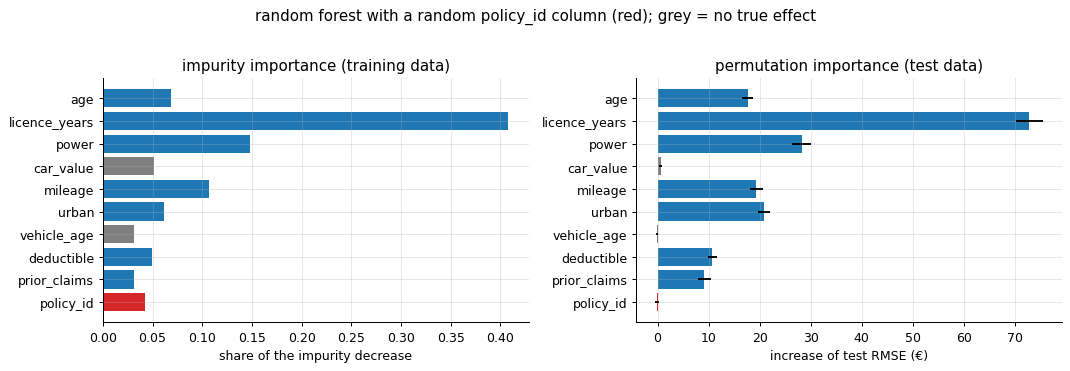

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = np.arange(len(FEATS_ID))[::-1]
cols = ["tab:red" if n == "policy_id" else ("tab:gray" if n in ("car_value", "vehicle_age") else "tab:blue") for n in FEATS_ID]
axes[0].barh(order, rf_id.feature_importances_, color=cols)
axes[0].set_title("impurity importance (training data)"); axes[0].set_xlabel("share of the impurity decrease")
axes[1].barh(order, imp_id.mean(1), xerr=imp_id.std(1), color=cols)
axes[1].set_title("permutation importance (test data)"); axes[1].set_xlabel("increase of test RMSE (€)")
for ax in axes:
    ax.set_yticks(order); ax.set_yticklabels(FEATS_ID)
plt.suptitle("random forest with a random policy_id column (red); grey = no true effect", y=1.02)
plt.tight_layout(); plt.show()

**What just happened?**
- **Impurity importance** ranks the random `policy_id` 8th of 10 with 0.043, ahead of `vehicle_age` (0.032) and of `prior_claims` (0.032), a real effect of +90 € per claim. `car_value`, which has no effect, gets 0.052, more than `deductible` (0.049), which is worth up to 150 €. Fully grown trees end in tiny leaves, and the last splits fit the noise of the training set with any column that has many distinct values; the ID has 4,000.
- **Permutation importance** on test data puts all three useless columns at zero: `policy_id` $-0.1$ €, `vehicle_age` $-0.1$ €, `car_value` 0.6 €. Fitting noise does not help on new data.
- Our implementation agrees with `sklearn.inspection.permutation_importance` to 0.71 € at most; the two use different random shuffles, and one estimate has a standard deviation of up to 2.6 €.
- Note also how the forest splits mostly on `licence_years` (0.408) rather than `age` (0.069): with near-duplicate features, which one a tree picks is close to arbitrary.

**The correlated-feature caveat.** Shuffling `age` alone creates policies such as a 25-year-old with 40 years of licence: rows that never occur. The model is then judged on inputs it was never trained on. And the question permutation importance answers is "how much does the model use this column?", not "how much information does this column carry?". With a correlated twin, a model refitted *without* `age` can recover most of its information from `licence_years`. The **drop-column importance** (refit without the feature, compare test errors) answers that second question, at the cost of $M$ refits. We compare both for the gradient-boosting model, the black box we explain in the rest of the lab.

In [8]:
base_hgb, imp_hgb = perm_importance(hgb.predict, X_te, y_te, n_repeats=10)
drop = np.zeros(M)
for j in range(M):
    keep = [k for k in range(M) if k != j]
    m_j = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=20,
                                        random_state=0).fit(X_tr[:, keep], y_tr)
    drop[j] = rmse(y_te, m_j.predict(X_te[:, keep])) - base_hgb
print(f"gradient boosting: test RMSE {base_hgb:.1f} €")
print(f"{'feature':14s} {'permutation':>12s} {'drop-column':>12s}")
for j, name in enumerate(FEATS):
    print(f"{name:14s} {imp_hgb[j].mean():10.1f} € {drop[j]:10.1f} €")
Xp = X_te.copy(); Xp[:, 0] = np.random.default_rng(0).permutation(Xp[:, 0])
impossible = (Xp[:, 1] > Xp[:, 0] - 18) | (Xp[:, 1] < Xp[:, 0] - 28)
print(f"after shuffling age, {impossible.mean():.0%} of the test rows are impossible (licence_years outside age − 28 … age − 18)")

gradient boosting: test RMSE 124.1 €
feature         permutation  drop-column
age                  29.7 €        3.2 €
licence_years        59.6 €        7.1 €
power                32.6 €        4.0 €
car_value             0.6 €       -0.7 €
mileage              22.8 €       12.2 €
urban                22.2 €       11.5 €
vehicle_age           0.1 €        0.3 €
deductible           14.9 €        7.0 €
prior_claims         13.3 €        7.8 €
after shuffling age, 85% of the test rows are impossible (licence_years outside age − 28 … age − 18)


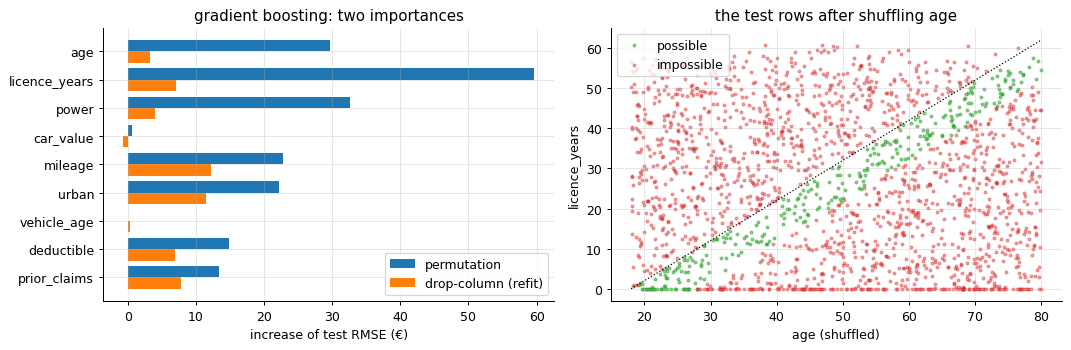

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
yy = np.arange(M)[::-1]
axes[0].barh(yy + 0.2, imp_hgb.mean(1), height=0.4, label="permutation")
axes[0].barh(yy - 0.2, drop, height=0.4, label="drop-column (refit)")
axes[0].set_yticks(yy); axes[0].set_yticklabels(FEATS); axes[0].set_xlabel("increase of test RMSE (€)")
axes[0].set_title("gradient boosting: two importances"); axes[0].legend()
axes[1].scatter(Xp[~impossible, 0], Xp[~impossible, 1], s=5, color="tab:green", alpha=0.5, label="possible")
axes[1].scatter(Xp[impossible, 0], Xp[impossible, 1], s=5, color="tab:red", alpha=0.4, label="impossible")
axes[1].plot([18, 80], [0, 62], "k:", lw=1)
axes[1].set_xlabel("age (shuffled)"); axes[1].set_ylabel("licence_years"); axes[1].set_title("the test rows after shuffling age")
axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.**
- Shuffling `age` raises the test RMSE by 29.7 €, but refitting the model *without* `age` costs only 3.2 €: `licence_years` carries almost the same information. The same holds the other way round (59.6 € against 7.1 €) and for `power`, which `car_value` can replace (32.6 € against 4.0 €). Features without a twin, `mileage` (22.8 € against 12.2 €) and `urban` (22.2 € against 11.5 €), are important by both measures.
- After shuffling `age`, 85% of the test rows are impossible policies: the permutation importance of `age` measures how badly the model behaves on such rows, not only how much it uses `age`.
- The two numbers answer different questions. Permutation: *how much does this fitted model rely on the column?* Drop-column: *how much information does the column add to the others?* Neither is the importance of the feature in the world. With correlated features, shuffle the correlated group together or report both.

## 4. Partial dependence and ICE curves

The **partial dependence** of $f$ on feature $j$ is the average prediction when feature $j$ is set to $z$ for *every* policy, the other features keeping their observed values:

$$\mathrm{PD}_j(z) = \mathbb{E}_{\mathbf{X}}\big[f(z, \mathbf{X}_{-j})\big] \approx \frac1n\sum_{i=1}^n f(z, \mathbf{x}_{i,-j}).$$

Computation: for each grid value $z$, copy the data, overwrite column $j$ with $z$, predict, average. If $f$ is additive, $f = g_j(x_j) + h(\mathbf{x}_{-j})$, then $\mathrm{PD}_j(z) = g_j(z) + \text{const}$: the PDP recovers the shape exactly.

An average can hide heterogeneity. The **individual conditional expectation** (ICE) curves keep the $n$ curves $z \mapsto f(z, \mathbf{x}_{i,-j})$, one per policy; the PDP is their mean. If the curves are parallel, there is no interaction with feature $j$; if they fan out, there is. **Centred ICE** curves subtract each curve's value at the left end of the grid, so that only the shapes are compared.

In [10]:
def ice_curves(predict, X, j, grid):
    """ICE from scratch: one row per policy, one column per grid value. The PDP is the column mean."""
    out = np.empty((len(X), len(grid)))
    for k, z in enumerate(grid):
        Xz = X.copy(); Xz[:, j] = z
        out[:, k] = predict(Xz)
    return out

jp = J["power"]; grid_p = np.linspace(50, 220, 35)
ice_p = ice_curves(hgb.predict, X_te, jp, grid_p); pdp_p = ice_p.mean(0)
skpd = partial_dependence(hgb, X_te, [jp], custom_values={jp: grid_p}, method="brute", kind="both")
print("max |PDP ours − sklearn| :", np.abs(pdp_p - skpd["average"][0]).max())
print("max |ICE ours − sklearn| :", np.abs(ice_p - skpd["individual"][0]).max())
assert np.allclose(pdp_p, skpd["average"][0]) and np.allclose(ice_p, skpd["individual"][0])

young = X_te[:, 0] < 25
k120, k200 = np.argmin(np.abs(grid_p - 120)), np.argmin(np.abs(grid_p - 200))
slope = (ice_p[:, k200] - ice_p[:, k120]) / (grid_p[k200] - grid_p[k120])
print(f"ICE slope between {grid_p[k120]:.0f} and {grid_p[k200]:.0f} kW: under 25 {slope[young].mean():.2f} €/kW "
      f"(truth 5.8), 25 or older {slope[~young].mean():.2f} €/kW (truth 1.8); PDP slope {(pdp_p[k200] - pdp_p[k120]) / 80:.2f}")

max |PDP ours − sklearn| : 2.0463630789890885e-12
max |ICE ours − sklearn| : 0.0
ICE slope between 120 and 200 kW: under 25 3.92 €/kW (truth 5.8), 25 or older 1.16 €/kW (truth 1.8); PDP slope 1.50


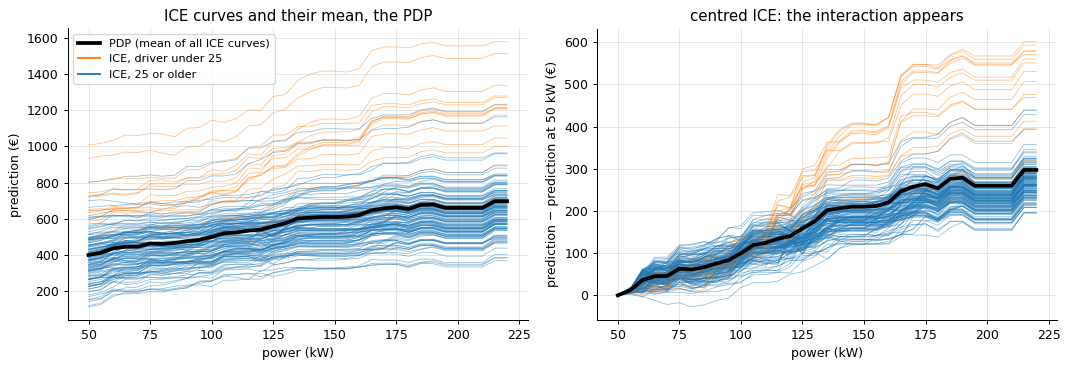

In [11]:
rng_plot = np.random.default_rng(3); show = rng_plot.choice(len(X_te), 150, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, centred in zip(axes, [False, True]):
    for i in show:
        c = ice_p[i] - (ice_p[i, 0] if centred else 0)
        ax.plot(grid_p, c, color="tab:orange" if young[i] else "tab:blue", lw=0.6, alpha=0.5)
    P = pdp_p - (pdp_p[0] if centred else 0)
    ax.plot(grid_p, P, "k", lw=3, label="PDP (mean of all ICE curves)")
    ax.plot([], [], color="tab:orange", label="ICE, driver under 25"); ax.plot([], [], color="tab:blue", label="ICE, 25 or older")
    ax.set_xlabel("power (kW)")
axes[0].set_ylabel("prediction (€)"); axes[0].set_title("ICE curves and their mean, the PDP"); axes[0].legend(fontsize=9)
axes[1].set_ylabel("prediction − prediction at 50 kW (€)"); axes[1].set_title("centred ICE: the interaction appears")
plt.tight_layout(); plt.show()

**What just happened?**
- Our ICE and PDP equal scikit-learn's to $2\times10^{-12}$.
- Between 120 and 200 kW the ICE curves of drivers under 25 rise by 3.92 €/kW, those of older drivers by 1.16 €/kW; the PDP, their average, by 1.50 €/kW. The **PDP hides the interaction**, the centred ICE curves show it as two bundles. The truth is 5.8 and 1.8 €/kW: the model learned the interaction but underestimates it, as only 11% of the policies are under 25 and few of those have powerful cars.
- The curves are staircases: a tree ensemble is piecewise constant, so "the slope at a point" of such a model is zero or undefined. Effects of tree models are only meaningful over a range.

**The extrapolation problem.** The PDP of `age` at $z = 22$ evaluates the model on every policy with its age overwritten by 22, *keeping its licence_years*: a 22-year-old with 35 years of licence. With correlated features most of these rows lie outside the data, where the model was never trained and its predictions are arbitrary.

In [12]:
ja, jl = J["age"], J["licence_years"]
grid_a = np.linspace(19, 78, 40)
pdp_a = ice_curves(hgb.predict, X_te, ja, grid_a).mean(0)
pdp_a_true = ice_curves(true_cost, X_te, ja, grid_a).mean(0)
share_out = [np.mean((X_te[:, jl] > z - 18) | (X_te[:, jl] < z - 28)) for z in grid_a]
for z in [22, 40, 70]:
    k = np.argmin(np.abs(grid_a - z))
    print(f"PDP of age at {grid_a[k]:.0f}: {share_out[k]:.0%} of the evaluated rows are impossible")
print(f"PDP drop from age 19 to age 40: model {pdp_a[0] - pdp_a[np.argmin(np.abs(grid_a - 40))]:.0f} €, "
      f"truth {pdp_a_true[0] - pdp_a_true[np.argmin(np.abs(grid_a - 40))]:.0f} €")

PDP of age at 22: 85% of the evaluated rows are impossible
PDP of age at 40: 84% of the evaluated rows are impossible
PDP of age at 70: 84% of the evaluated rows are impossible
PDP drop from age 19 to age 40: model 177 €, truth 257 €


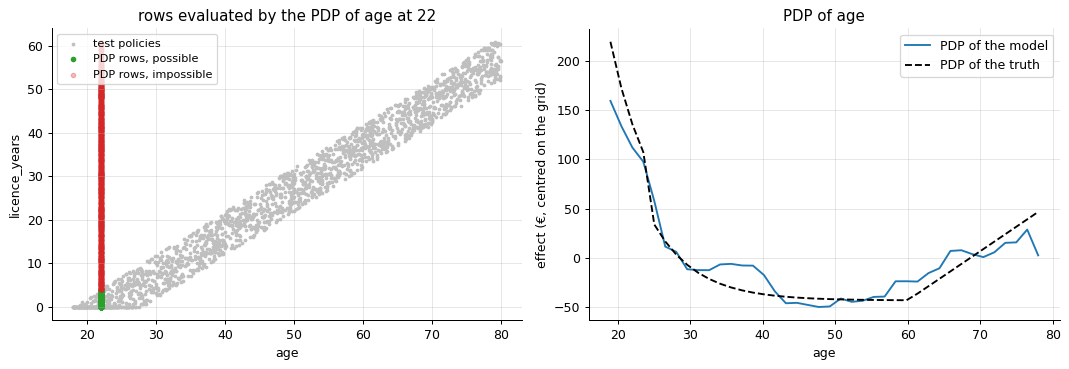

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
z = 22; inside = (X_te[:, jl] <= z - 18) & (X_te[:, jl] >= z - 28)
axes[0].scatter(X_te[:, ja], X_te[:, jl], s=4, color="0.75", label="test policies")
axes[0].scatter(np.full(inside.sum(), z), X_te[inside, jl], s=12, color="tab:green", label="PDP rows, possible")
axes[0].scatter(np.full((~inside).sum(), z), X_te[~inside, jl], s=12, color="tab:red", alpha=0.3, label="PDP rows, impossible")
axes[0].set_xlabel("age"); axes[0].set_ylabel("licence_years"); axes[0].set_title(f"rows evaluated by the PDP of age at {z}")
axes[0].legend(loc="upper left", fontsize=9)
axes[1].plot(grid_a, pdp_a - pdp_a.mean(), label="PDP of the model")
axes[1].plot(grid_a, pdp_a_true - pdp_a_true.mean(), "k--", label="PDP of the truth")
axes[1].set_xlabel("age"); axes[1].set_ylabel("effect (€, centred on the grid)"); axes[1].set_title("PDP of age"); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation.** At age 22, 85% of the rows that the PDP averages are impossible (84% at 40 and at 70). From age 19 to 40 the PDP of the model drops by 177 €, the truth by 257 €: the PDP flattens the effect of youth. At "22 years old with 35 years of licence" the trees apply the low-risk branches they learned for experienced drivers, and the average is pulled down. The PDP of the truth is right because $\mu$ is defined, and additive in age, everywhere; a fitted model has no such guarantee outside the data.

## 5. ALE plots and a global surrogate tree

**Accumulated local effects** (Apley and Zhu, 2020) avoid the impossible rows. Cut the range of $x_j$ into bins at its quantiles $z_0 \lt z_1 \lt \dots \lt z_K$. For bin $k$ take only the policies whose $x_j$ falls in that bin, move them to the two edges of the bin, and average the difference of predictions:

$$\Delta_k = \frac{1}{n_k}\sum_{i:\,x_{ij}\in(z_{k-1}, z_k]}\Big[f(z_k, \mathbf{x}_{i,-j}) - f(z_{k-1}, \mathbf{x}_{i,-j})\Big], \qquad \mathrm{ALE}_j(z_K) = \sum_{k\le K}\Delta_k - \text{const}.$$

Each row moves only within its own small bin, so it stays a realistic policy. The constant centres the curve (mean effect over the data = 0). For a linear model the differences are exactly $\beta_j(z_k - z_{k-1})$, so the ALE is a straight line of slope $\beta_j$: we check it.

In [14]:
def ale_curve(predict, X, j, n_bins=20):
    """First-order ALE from scratch. Returns the bin edges and the centred ALE at the edges."""
    edges = np.unique(np.quantile(X[:, j], np.linspace(0, 1, n_bins + 1)))
    b = np.clip(np.searchsorted(edges, X[:, j], side="left"), 1, len(edges) - 1)   # row i is in (edges[b-1], edges[b]]
    lo, hi = X.copy(), X.copy()
    lo[:, j], hi[:, j] = edges[b - 1], edges[b]
    diff = predict(hi) - predict(lo)
    counts = np.bincount(b, minlength=len(edges))[1:]
    effects = np.bincount(b, weights=diff, minlength=len(edges))[1:] / np.maximum(counts, 1)
    ale = np.concatenate([[0.0], np.cumsum(effects)])
    ale -= np.sum(counts * (ale[1:] + ale[:-1]) / 2) / counts.sum()
    return edges, ale

e_lin, a_lin = ale_curve(lin.predict, X_te, ja)
print("ALE slopes of the linear model:", np.unique(np.round(np.diff(a_lin) / np.diff(e_lin), 6)), " coefficient:", round(lin.coef_[ja], 6))
assert np.allclose(np.diff(a_lin) / np.diff(e_lin), lin.coef_[ja])

def centred_pdp(predict, X, j, grid):
    pd_ = ice_curves(predict, X, j, grid).mean(0)
    return pd_ - np.interp(X[:, j], grid, pd_).mean()

def curve_error(X, j, grid, c, c_ref):       # RMSE between two curves, weighted by the data
    return rmse(np.interp(X[:, j], grid, c), np.interp(X[:, j], grid, c_ref))

res = {}
for mname, model in [("gradient boosting", hgb), ("random forest", rf)]:
    for name in ["age", "licence_years"]:
        j = J[name]
        edges, ale_m = ale_curve(model.predict, X_te, j)
        _, ale_t = ale_curve(true_cost, X_te, j)
        pdp_m = centred_pdp(model.predict, X_te, j, edges)
        res[mname, name] = (edges, ale_m, ale_t, pdp_m)
        print(f"{mname:17s} {name:13s} at {edges[0]:.0f}: truth {ale_t[0]:4.0f} €, ALE {ale_m[0]:4.0f} €, PDP {pdp_m[0]:4.0f} €"
              f"  | error vs truth: ALE {curve_error(X_te, j, edges, ale_m, ale_t):4.1f} €, PDP {curve_error(X_te, j, edges, pdp_m, ale_t):4.1f} €")

ALE slopes of the linear model: [-9.451]  coefficient: -9.451433
gradient boosting age           at 18: truth  244 €, ALE  184 €, PDP  165 €  | error vs truth: ALE 14.4 €, PDP 17.4 €


gradient boosting licence_years at 0: truth  267 €, ALE  288 €, PDP  248 €  | error vs truth: ALE 12.8 €, PDP 13.7 €


random forest     age           at 18: truth  244 €, ALE  139 €, PDP   64 €  | error vs truth: ALE 24.7 €, PDP 38.7 €


random forest     licence_years at 0: truth  267 €, ALE  300 €, PDP  306 €  | error vs truth: ALE 19.6 €, PDP 20.7 €


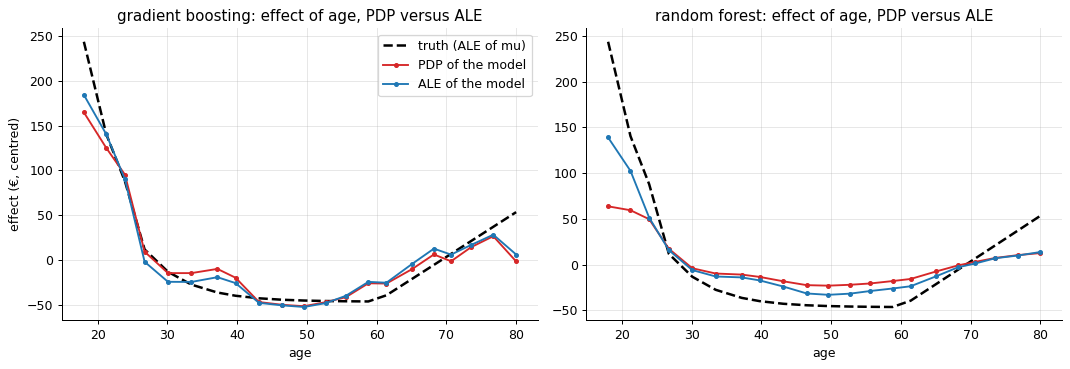

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, mname in zip(axes, ["gradient boosting", "random forest"]):
    edges, ale_m, ale_t, pdp_m = res[mname, "age"]
    ax.plot(edges, ale_t, "k--", lw=2, label="truth (ALE of mu)")
    ax.plot(edges, pdp_m, "o-", ms=3, color="tab:red", label="PDP of the model")
    ax.plot(edges, ale_m, "o-", ms=3, color="tab:blue", label="ALE of the model")
    ax.set_xlabel("age"); ax.set_title(f"{mname}: effect of age, PDP versus ALE")
axes[0].set_ylabel("effect (€, centred)"); axes[0].legend()
plt.tight_layout(); plt.show()

**What just happened?**
- For the linear model every ALE slope equals the coefficient, $-9.451$: the implementation is right.
- **Gradient boosting**, effect of being 18 relative to the average: truth 244 €, ALE 184 €, PDP 165 €; average error over the data 14.4 € for ALE against 17.4 € for the PDP. **Random forest**: truth 244 €, ALE 139 €, PDP only 64 €; errors 24.7 € against 38.7 €. The forest's PDP almost erases the youth effect, because a forest extrapolates even more crudely than boosting (its leaves average whole neighbourhoods).
- ALE is closer, but not perfect. With $\rho = 0.987$ the data barely say whether youth or inexperience is responsible, and both models put more on `licence_years` than the truth (ALE at 0 years: 288 € and 300 € against 267 €). **ALE fixes extrapolation; it cannot fix the attribution between near-duplicate features.** Nothing can, without more data or assumptions.

**A global surrogate.** Fit an interpretable model to the *predictions* of the black box (not to $y$) and read the interpretable model. Its **fidelity** is the $R^2$ between surrogate and black box on new data: a surrogate with low fidelity explains a different model.

fidelity R² (surrogate vs gradient boosting, test): {1: 0.466, 2: 0.582, 3: 0.657, 4: 0.712, 5: 0.767, 6: 0.814, 7: 0.848, 8: 0.862}
depth-3 surrogate: fidelity 0.657, R² against the observed cost 0.468


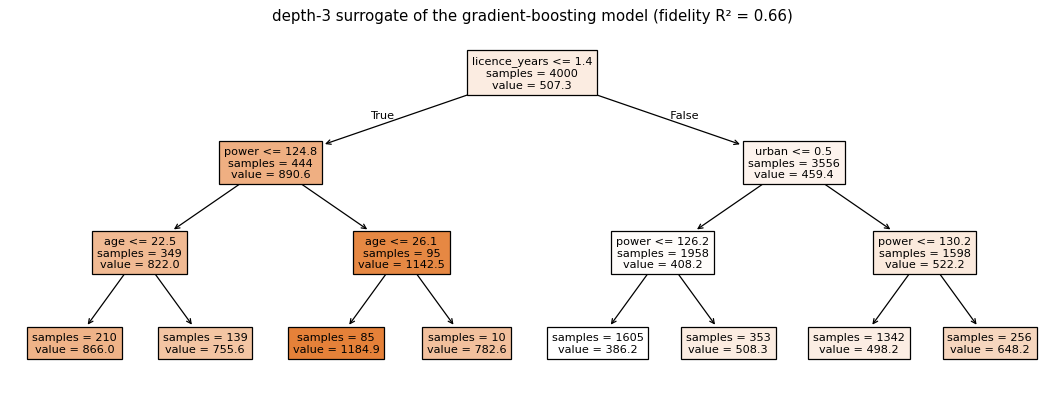

In [16]:
f_tr, f_te = hgb.predict(X_tr), hgb.predict(X_te)
fid = {}
for d in range(1, 9):
    s = DecisionTreeRegressor(max_depth=d, random_state=0).fit(X_tr, f_tr)
    fid[d] = r2_score(f_te, s.predict(X_te))
print("fidelity R² (surrogate vs gradient boosting, test):", {d: round(v, 3) for d, v in fid.items()})
surrogate = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X_tr, f_tr)
print(f"depth-3 surrogate: fidelity {fid[3]:.3f}, R² against the observed cost {r2_score(y_te, surrogate.predict(X_te)):.3f}")
fig, ax = plt.subplots(figsize=(15, 5.2))
plot_tree(surrogate, feature_names=FEATS, filled=True, impurity=False, precision=1, fontsize=9, ax=ax)
ax.set_title(f"depth-3 surrogate of the gradient-boosting model (fidelity R² = {fid[3]:.2f})")
plt.show()

**Interpretation.** The depth-3 surrogate has a fidelity of 0.657: it reproduces two thirds of the variance of the boosting model's predictions (depth 8: 0.862, but then it is no longer readable). Its rules are sensible: the most expensive leaf is "licence_years ≤ 1.4, power > 124.8 kW, age ≤ 26.1": 1,185 € for 85 policies, the young-novice-powerful-car interaction. A surrogate is a good summary to show, but a third of what the black box does is not in it.

## 6. Shapley values, exactly

Local question: why does the model predict $f(\mathbf{x})$ for *this* policy, rather than the average $\mathbb{E}[f(\mathbf{X})]$? Shapley (1953) answered the analogous question in cooperative game theory: $M$ players cooperate and earn a payoff; how to split it fairly? Here the **players are the features** and the **payoff of a coalition** $S$ is

$$v(S) = \mathbb{E}\big[f(\mathbf{x}_S, \mathbf{X}_{\bar S})\big] \quad\text{(interventional value function)},$$

the average prediction when the features in $S$ take the values of our policy and the others are drawn from a background sample. $v(\varnothing)$ is the average prediction, $v(\{1..M\}) = f(\mathbf{x})$. The **Shapley value** of feature $j$ is its marginal contribution averaged over all orders in which the features can join:

$$\phi_j = \sum_{S \subseteq \{1..M\}\setminus\{j\}} \frac{|S|!\,(M-|S|-1)!}{M!}\,\big[v(S\cup\{j\}) - v(S)\big].$$

The weight is the fraction of the $M!$ orderings in which exactly the features of $S$ arrive before $j$. It is the unique attribution with four properties: **efficiency** $\sum_j\phi_j = f(\mathbf{x}) - v(\varnothing)$; **symmetry** (two features that always contribute the same get the same value); **dummy** (a feature that never changes $v$ gets 0); **additivity** (the values of $f + g$ are the sums). Lundberg and Lee (2017) called these attributions **SHAP values**.

### 6a. A worked example with three features

A toy pricing model with three features, `young` (0/1), `power` (kW) and `urban` (0/1), with an interaction between youth and power:

$$f = 300 + 200\,\text{young} + 2\,(\text{power}-100) + 2\,\text{young}\,(\text{power}-100) + 100\,\text{urban}.$$

We explain the policy $\mathbf{x} = (1, 150, 1)$ against a background of four policies. The same numbers are on the slides.

In [17]:
def toy_f(Z):
    young, power, urban = Z.T
    return 300 + 200 * young + 2 * (power - 100) + 2 * young * (power - 100) + 100 * urban

toy_bg = np.array([[0, 80, 0], [0, 100, 1], [1, 120, 0], [0, 140, 1.]])
toy_x = np.array([1, 150, 1.])
TOY = ["young", "power", "urban"]

def all_masks(m):
    """All 2^m coalitions as boolean rows (row k = binary digits of k, feature 0 = lowest bit)."""
    return ((np.arange(2 ** m)[:, None] >> np.arange(m)) & 1).astype(bool)

def coalition_values(f, x, background, masks):
    """Interventional v(S) for every mask: features in S from x, the others from each background row; average."""
    Z = np.where(masks[:, None, :], x[None, None, :], background[None, :, :]).reshape(-1, len(x))
    return f(Z).reshape(len(masks), len(background)).mean(1)

def shapley_from_values(v, m):
    """Exact Shapley values from the 2^m coalition values (indexed by the binary code of the coalition)."""
    masks = all_masks(m); size = masks.sum(1)
    w = np.array([math.factorial(s) * math.factorial(m - s - 1) / math.factorial(m) for s in range(m)])
    phi = np.zeros(m)
    for j in range(m):
        S = np.where(~masks[:, j])[0]                  # coalitions without j (their code), and with j added
        phi[j] = np.sum(w[size[S]] * (v[S | (1 << j)] - v[S]))
    return phi

masks3 = all_masks(3)
v3 = coalition_values(toy_f, toy_x, toy_bg, masks3)
print("background predictions:", toy_f(toy_bg), " -> v(∅) =", v3[0])
for k in np.argsort(masks3.sum(1), kind="stable"):
    print(f"  v({{{', '.join(n for n, s in zip(TOY, masks3[k]) if s)}}}) = {v3[k]:.0f}")
phi3 = shapley_from_values(v3, 3)
# the same values by averaging marginal contributions over the 3! = 6 orderings
phi_orders = np.zeros(3)
for order in itertools.permutations(range(3)):
    code = 0
    for j in order:
        phi_orders[j] += v3[code | (1 << j)] - v3[code]; code |= 1 << j
phi_orders /= 6
print("Shapley values:", {n: round(float(p), 2) for n, p in zip(TOY, phi3)}, "  by the 6 orderings:", phi_orders.round(2))
print(f"efficiency: sum = {phi3.sum():.1f} = f(x) − v(∅) = {toy_f(toy_x[None])[0]:.0f} − {v3[0]:.0f}")
assert np.allclose(phi3, phi_orders) and np.isclose(phi3.sum(), toy_f(toy_x[None])[0] - v3[0])
assert np.isclose(phi3[2], 100 * (toy_x[2] - toy_bg[:, 2].mean()))      # additive term: beta * (x - mean)
sym = shapley_from_values(coalition_values(lambda Z: Z[:, 0] * Z[:, 1], np.array([2., 2.]), np.zeros((1, 2)), all_masks(2)), 2)
assert np.isclose(sym[0], sym[1])                                        # symmetry: x1*x2 at (2, 2) splits 4 into 2 + 2

background predictions: [260. 400. 580. 480.]  -> v(∅) = 430.0
  v({}) = 430
  v({young}) = 590
  v({power}) = 525
  v({urban}) = 480
  v({young, power}) = 750
  v({young, urban}) = 640
  v({power, urban}) = 575
  v({young, power, urban}) = 800
Shapley values: {'young': 192.5, 'power': 127.5, 'urban': 50.0}   by the 6 orderings: [192.5 127.5  50. ]
efficiency: sum = 370.0 = f(x) − v(∅) = 800 − 430


**What just happened?** The eight coalition values are on the slides: $v(\varnothing) = 430$, $v(\{\text{young}\}) = 590$, …, $v(\{\text{young, power, urban}\}) = 800$. The Shapley values are **young 192.5, power 127.5, urban 50**, by the weighted formula and by averaging over the 6 orderings; they sum to $370 = 800 - 430$ (efficiency).

- `urban` enters $f$ additively, so its value is $100\times(1 - 0.5)$: its effect times the gap between the policy (1) and the background mean (0.5).
- The interaction term $2\,\text{young}\,(\text{power}-100)$ is worth $100$ at $\mathbf{x}$ and $10$ on average over the background; its 90 € are shared between young (42.5) and power (47.5). An interaction has no "owner": Shapley values split it.

### 6b. All nine features of the portfolio model

With $M = 9$ there are $2^9 = 512$ coalitions; with a background of 100 policies that is 51,200 predictions for one explanation. Cheap for gradient boosting. We explain policy A with the gradient-boosting model, and with the **truth $\mu$ used as if it were the model**: then we know what a correct attribution looks like. Three checks: efficiency; the dummy axiom on $\mu$ (it never reads `car_value` or `vehicle_age`, so they must get exactly 0); and the closed form for a linear model, $\phi_j = \beta_j\,(x_j - \bar x_j)$ with $\bar x_j$ the background mean.

In [18]:
masks9 = all_masks(M)
background = X_tr[np.random.default_rng(4).choice(len(X_tr), 100, replace=False)]
t0 = time.time()
v_A = coalition_values(hgb.predict, policy_A, background, masks9)
phi_A = shapley_from_values(v_A, M)
print(f"512 coalitions x 100 background rows in {time.time() - t0:.2f} s")
f_A = hgb.predict(policy_A[None])[0]
print(f"policy A: prediction {f_A:.0f} €, baseline v(∅) = {v_A[0]:.0f} €, sum of SHAP values {phi_A.sum():.1f} €")
assert np.isclose(phi_A.sum(), f_A - v_A[0])                           # efficiency

phi_A_true = shapley_from_values(coalition_values(true_cost, policy_A, background, masks9), M)
assert phi_A_true[J["car_value"]] == 0 and phi_A_true[J["vehicle_age"]] == 0   # dummy: mu never reads them
phi_lin = shapley_from_values(coalition_values(lin.predict, policy_A, background, masks9), M)
assert np.allclose(phi_lin, lin.coef_ * (policy_A - background.mean(0)))     # linear closed form
print(f"{'feature':14s} {'x':>6s} {'SHAP (model)':>13s} {'SHAP (truth)':>13s}")
for j, name in enumerate(FEATS):
    print(f"{name:14s} {policy_A[j]:6.0f} {phi_A[j]:11.1f} € {phi_A_true[j]:11.1f} €")

512 coalitions x 100 background rows in 0.13 s
policy A: prediction 1108 €, baseline v(∅) = 528 €, sum of SHAP values 580.1 €
feature             x  SHAP (model)  SHAP (truth)
age                21       163.4 €       225.8 €
licence_years       2        46.5 €        66.4 €
power             160       181.0 €       228.1 €
car_value          35        -2.6 €         0.0 €
mileage            22        39.7 €        61.4 €
urban               1        65.1 €        57.6 €
vehicle_age         8        -9.7 €         0.0 €
deductible          0        48.2 €        54.0 €
prior_claims        1        48.6 €        67.5 €


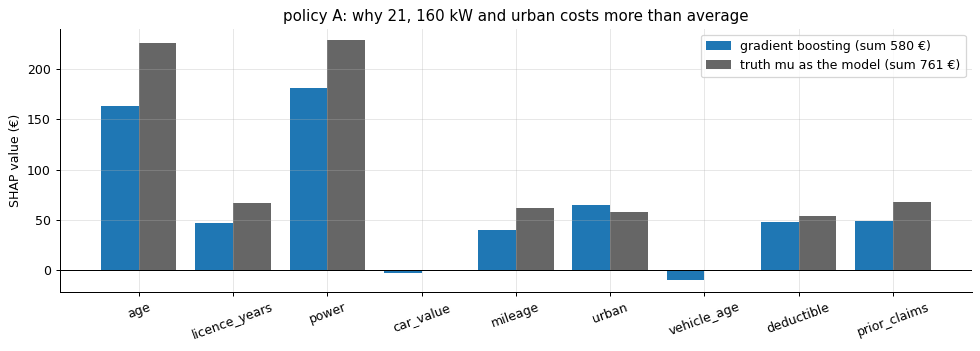

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
xx = np.arange(M)
ax.bar(xx - 0.2, phi_A, 0.4, label=f"gradient boosting (sum {phi_A.sum():.0f} €)")
ax.bar(xx + 0.2, phi_A_true, 0.4, color="0.4", label=f"truth mu as the model (sum {phi_A_true.sum():.0f} €)")
ax.axhline(0, color="k", lw=0.8); ax.set_xticks(xx); ax.set_xticklabels(FEATS, rotation=20)
ax.set_ylabel("SHAP value (€)"); ax.set_title("policy A: why 21, 160 kW and urban costs more than average"); ax.legend()
plt.tight_layout(); plt.show()

**What just happened?**
- One explanation costs 51,200 predictions: 0.1 s. Policy A: prediction 1,108 €, baseline $v(\varnothing) = 528$ €, and the nine SHAP values add up to exactly the difference, 580.1 €.
- The checks pass: with the truth as the model, `car_value` and `vehicle_age` get exactly 0 (dummy); for the linear model the SHAP values equal $\beta_j(x_j - \bar x_j)$.
- The model and the truth agree on the story (power +181 € vs +228 €, age +163 € vs +226 €, then urban, deductible 0, one past claim, licence, mileage), but the model is 176 € below the true cost of policy A (1,108 € vs 1,284 €): it learned only part of the young-driver interaction, as section 4 showed. The model gives small values to the useless features (`car_value` $-2.6$ €, `vehicle_age` $-9.7$ €): fitted noise, and a reminder that SHAP explains the model, errors included.

### 6c. Interventional or conditional value function?

The interventional $v(S)$ fills the missing features with background values *independently of* $\mathbf{x}_S$: it creates the same impossible rows as the PDP (a 21-year-old with 40 years of licence). The alternative is the **conditional** (observational) value function

$$v_{\text{cond}}(S) = \mathbb{E}\big[f(\mathbf{x}_S, \mathbf{X}_{\bar S}) \mid \mathbf{X}_S = \mathbf{x}_S\big],$$

which fills the missing features with values that are plausible *given* the known ones. We estimate it crudely with nearest neighbours: take the 50 training policies closest to $\mathbf{x}$ on the features in $S$ (in standard deviations) and use their other features. The two choices answer different questions: interventional is "true to the model" (credit only for what $f$ reads), conditional is "true to the data" (credit also for what a feature *reveals* about others). The difference shows up with correlated features.

In [20]:
scale = X_tr.std(0)
def conditional_values(f, x, pool, masks, k=50):
    """v_cond(S) by k nearest neighbours on the features in S."""
    v = np.empty(len(masks)); base = f(pool).mean()
    for c, S in enumerate(masks):
        if not S.any():
            v[c] = base; continue
        d = (((pool[:, S] - x[S]) / scale[S]) ** 2).sum(1)
        Z = pool[np.argpartition(d, k)[:k]].copy(); Z[:, S] = x[S]
        v[c] = f(Z).mean()
    return v

bg400 = X_tr[np.random.default_rng(5).choice(len(X_tr), 400, replace=False)]
cmp = {}
for name, f in [("truth mu", true_cost), ("gradient boosting", hgb.predict)]:
    phi_int = shapley_from_values(coalition_values(f, policy_A, bg400, masks9), M)
    phi_cond = shapley_from_values(conditional_values(f, policy_A, X_tr, masks9), M)
    cmp[name] = (phi_int, phi_cond)
    print(f"\n{name}: {'interventional':>15s} {'conditional':>12s}")
    for j in [J["age"], J["licence_years"], J["power"], J["car_value"]]:
        print(f"  {FEATS[j]:14s} {phi_int[j]:13.1f} € {phi_cond[j]:10.1f} €")


truth mu:  interventional  conditional
  age                    244.3 €      291.1 €
  licence_years           77.6 €       62.5 €
  power                  203.0 €      164.1 €
  car_value                0.0 €       50.3 €



gradient boosting:  interventional  conditional
  age                    175.9 €      245.5 €
  licence_years           61.8 €       27.1 €
  power                  161.7 €      121.0 €
  car_value               -2.8 €       44.9 €


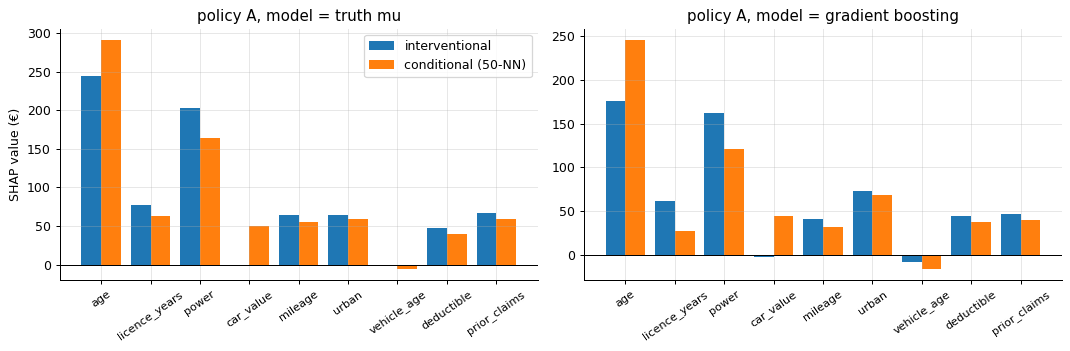

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (pi_, pc_)) in zip(axes, cmp.items()):
    ax.bar(xx - 0.2, pi_, 0.4, label="interventional"); ax.bar(xx + 0.2, pc_, 0.4, color="tab:orange", label="conditional (50-NN)")
    ax.axhline(0, color="k", lw=0.8); ax.set_xticks(xx); ax.set_xticklabels(FEATS, rotation=35, fontsize=9)
    ax.set_title(f"policy A, model = {name}")
axes[0].set_ylabel("SHAP value (€)"); axes[0].legend()
plt.tight_layout(); plt.show()

**Interpretation.** With the truth as the model, `car_value` gets **0 € interventionally but 50.3 € conditionally**, and `power` falls from 203 € to 164 €. $\mu$ never reads `car_value`, but *knowing* that the car is worth 35 k€ tells us that it is powerful, and the conditional game rewards that information. `age` goes from 244 € to 291 € and `licence_years` from 78 € to 62.5 €. The gradient-boosting model shows the same pattern (`car_value` $-2.8$ € → 44.9 €).

Which one is right depends on the question. To debug or audit **the model** ("which inputs does it use?"), use the interventional values: a feature the model ignores gets 0. To describe what the **data** reveal ("which information signals risk?"), the conditional values are the natural choice, but then a feature can get credit without being used, which is misleading in a regulatory explanation. The `shap` library is interventional with a background sample by default; its `tree_path_dependent` TreeSHAP approximates the conditional version.

## 7. KernelSHAP and the SHAP plots

With $M$ features the exact formula needs $2^M$ coalition values: fine for 9, hopeless for 50. **KernelSHAP** (Lundberg and Lee, 2017) recovers the Shapley values as the solution of a weighted linear regression. Encode a coalition as $\mathbf{z}\in\{0,1\}^M$ and fit $g(\mathbf{z}) = \phi_0 + \sum_j\phi_j z_j$ to $v(\mathbf{z})$ by weighted least squares, with the **Shapley kernel**

$$\pi(\mathbf{z}) = \frac{M-1}{\binom{M}{|\mathbf{z}|}\,|\mathbf{z}|\,(M-|\mathbf{z}|)},$$

and the constraints $\phi_0 = v(\varnothing)$, $\sum_j \phi_j = f(\mathbf{x}) - v(\varnothing)$ (the empty and full coalitions have infinite weight). With all coalitions the solution is exactly the Shapley values; with a sample of coalitions it is an estimate. The kernel puts most weight on very small and very large coalitions: they tell most about single features.

We impose the constraint by eliminating $\phi_M = \Delta - \sum_{j\lt M}\phi_j$, with $\Delta = f(\mathbf{x}) - v(\varnothing)$, and solve an ordinary weighted least-squares problem in $\phi_1..\phi_{M-1}$.

In [22]:
def shapley_kernel(m, s):
    return (m - 1) / (math.comb(m, s) * s * (m - s))

def kernel_shap_solve(Z, vZ, w, v0, vfull):
    """Constrained weighted least squares: Z (coalitions x M, 0/1), their values vZ, weights w."""
    delta = vfull - v0
    yv = vZ - v0 - Z[:, -1] * delta
    A = Z[:, :-1] - Z[:, [-1]]
    sw = np.sqrt(w)
    beta = np.linalg.lstsq(sw[:, None] * A, sw * yv, rcond=None)[0]     # least squares (minimum norm if rank-deficient)
    return np.append(beta, delta - beta.sum())

def kernel_shap_sampled(v_all, m, n_coal, seed):
    """Sample coalition sizes with probability proportional to the total kernel weight of each size, then a
    random coalition of that size and its complement (paired sampling); unit weights. v_all[code] = v(S)."""
    rng = np.random.default_rng(seed)
    sizes = np.arange(1, m); p = np.array([math.comb(m, s) * shapley_kernel(m, s) for s in sizes]); p /= p.sum()
    Z = []
    for _ in range(n_coal // 2):
        z = np.zeros(m, bool); z[rng.choice(m, rng.choice(sizes, p=p), replace=False)] = True
        Z += [z, ~z]
    Z = np.array(Z); codes = Z.astype(int) @ (1 << np.arange(m))
    return kernel_shap_solve(Z.astype(float), v_all[codes], np.ones(len(Z)), v_all[0], v_all[-1])

inner = masks9[1:-1]; s_in = inner.sum(1)
phi_kernel = kernel_shap_solve(inner.astype(float), v_A[1:-1], np.array([shapley_kernel(M, s) for s in s_in]), v_A[0], v_A[-1])
print("KernelSHAP with all 510 coalitions vs exact: max difference", np.abs(phi_kernel - phi_A).max())
assert np.allclose(phi_kernel, phi_A)
n_list = [16, 32, 64, 128, 256, 512, 1024]
err = {n: [rmse(kernel_shap_sampled(v_A, M, n, seed), phi_A) for seed in range(20)] for n in n_list}
for n in n_list:
    print(f"  {n:5d} sampled coalitions: RMSE to the exact SHAP values {np.mean(err[n]):6.2f} € (± {np.std(err[n]):.2f})")

KernelSHAP with all 510 coalitions vs exact: max difference 2.1316282072803006e-13


     16 sampled coalitions: RMSE to the exact SHAP values  29.76 € (± 19.98)
     32 sampled coalitions: RMSE to the exact SHAP values   8.27 € (± 13.42)
     64 sampled coalitions: RMSE to the exact SHAP values   2.45 € (± 0.64)
    128 sampled coalitions: RMSE to the exact SHAP values   1.65 € (± 0.29)
    256 sampled coalitions: RMSE to the exact SHAP values   1.09 € (± 0.24)
    512 sampled coalitions: RMSE to the exact SHAP values   0.74 € (± 0.18)
   1024 sampled coalitions: RMSE to the exact SHAP values   0.52 € (± 0.13)


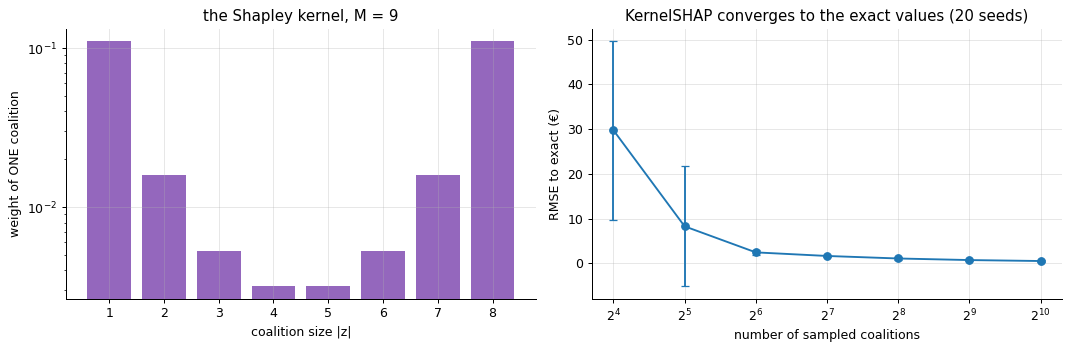

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ss = np.arange(1, M)
axes[0].bar(ss, [shapley_kernel(M, s) for s in ss], color="tab:purple")
axes[0].set_yscale("log"); axes[0].set_xlabel("coalition size |z|"); axes[0].set_ylabel("weight of ONE coalition")
axes[0].set_title(f"the Shapley kernel, M = {M}")
axes[1].errorbar(n_list, [np.mean(err[n]) for n in n_list], yerr=[np.std(err[n]) for n in n_list], marker="o", capsize=3)
axes[1].set_xscale("log", base=2); axes[1].set_xlabel("number of sampled coalitions"); axes[1].set_ylabel("RMSE to exact (€)")
axes[1].set_title("KernelSHAP converges to the exact values (20 seeds)")
plt.tight_layout(); plt.show()

**What just happened?** KernelSHAP with all 510 coalitions reproduces the exact values to $2\times10^{-13}$. With sampled coalitions the error falls from 29.8 € (16 coalitions) to 2.45 € (64) and 0.52 € (1,024), roughly as $1/\sqrt{n}$. The kernel weight of one coalition of size 1 or 8 is 0.111, that of a size-4 coalition 0.0032, 35 times less: the sampler spends its budget on the coalitions that isolate one feature.

**From local to global.** Explain many policies and look at all the SHAP values together. Because $M = 9$ we can afford the exact values for all 2,000 test policies (with a background of 20 policies: 10 million predictions, under a minute). The plots show 300 of them. Three standard plots:

- **beeswarm** (summary): one row per feature, one dot per policy at its SHAP value, coloured by the feature value. Spread = importance, colour = direction;
- **dependence plot**: SHAP value of one feature against its value; vertical spread at a given value reveals interactions;
- **waterfall**: one policy, from the baseline $\phi_0$ to $f(\mathbf{x})$ one feature at a time.

**TreeSHAP** (Lundberg et al., 2020) computes SHAP values of tree ensembles in polynomial time by walking down the trees, which is what the `shap` library uses for XGBoost, LightGBM and scikit-learn forests.

In [24]:
bg20 = X_tr[np.random.default_rng(7).choice(len(X_tr), 20, replace=False)]
t0 = time.time()
V_te = np.array([coalition_values(hgb.predict, x, bg20, masks9) for x in X_te])
PHI = np.array([shapley_from_values(v, M) for v in V_te])
print(f"exact SHAP values of the {len(X_te)} test policies (background of 20): {time.time() - t0:.0f} s")
gap = PHI.sum(1) - (hgb.predict(X_te) - V_te[:, 0])
print(f"additivity: max |sum of SHAP − (f(x) − v(∅))| = {np.abs(gap).max():.1e}")
assert np.allclose(gap, 0)
mean_abs = np.abs(PHI).mean(0)
print("global importance, mean |SHAP|:", {FEATS[j]: round(float(mean_abs[j]), 1) for j in np.argsort(-mean_abs)})
print("permutation importance ranking:", [FEATS[j] for j in np.argsort(-imp_hgb.mean(1))])

exact SHAP values of the 2000 test policies (background of 20): 49 s
additivity: max |sum of SHAP − (f(x) − v(∅))| = 4.5e-13
global importance, mean |SHAP|: {'licence_years': 71.1, 'urban': 54.9, 'power': 52.1, 'mileage': 42.6, 'age': 40.5, 'deductible': 36.6, 'prior_claims': 32.2, 'car_value': 5.9, 'vehicle_age': 4.3}
permutation importance ranking: ['licence_years', 'power', 'age', 'mileage', 'urban', 'deductible', 'prior_claims', 'car_value', 'vehicle_age']


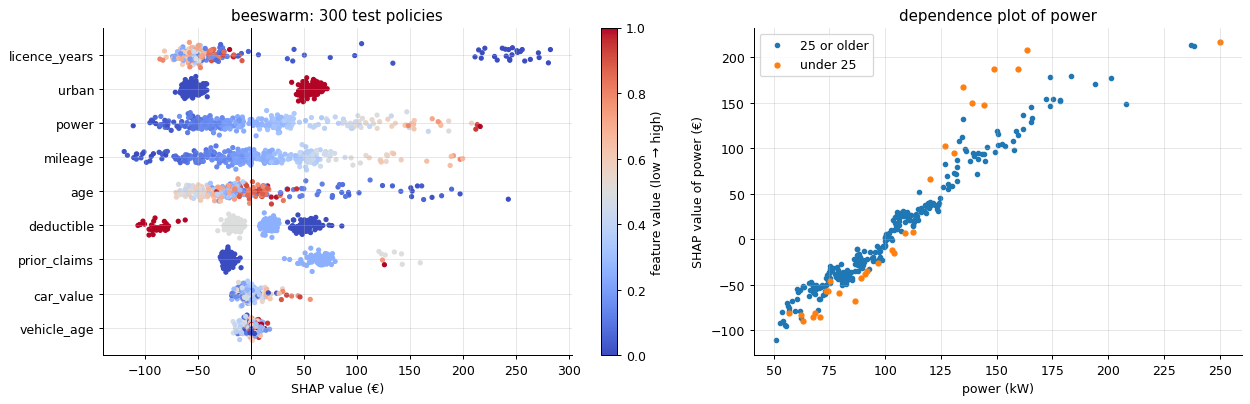

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.2, 1]})
order = np.argsort(mean_abs)
idx300 = np.random.default_rng(6).choice(len(X_te), 300, replace=False)
jit = np.random.default_rng(0).normal(0, 0.12, len(idx300))
for r, j in enumerate(order):
    v = X_te[idx300, j]; c = (v - X_te[:, j].min()) / (np.ptp(X_te[:, j]) + 1e-9)
    sc = axes[0].scatter(PHI[idx300, j], r + jit, c=c, cmap="coolwarm", s=10, vmin=0, vmax=1)
axes[0].set_yticks(range(M)); axes[0].set_yticklabels([FEATS[j] for j in order]); axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("SHAP value (€)"); axes[0].set_title("beeswarm: 300 test policies")
cb = plt.colorbar(sc, ax=axes[0]); cb.set_label("feature value (low → high)")
yo = X_te[idx300, 0] < 25
axes[1].scatter(X_te[idx300, jp][~yo], PHI[idx300, jp][~yo], s=12, label="25 or older")
axes[1].scatter(X_te[idx300, jp][yo], PHI[idx300, jp][yo], s=16, color="tab:orange", label="under 25")
axes[1].set_xlabel("power (kW)"); axes[1].set_ylabel("SHAP value of power (€)"); axes[1].set_title("dependence plot of power")
axes[1].legend()
plt.tight_layout(); plt.show()

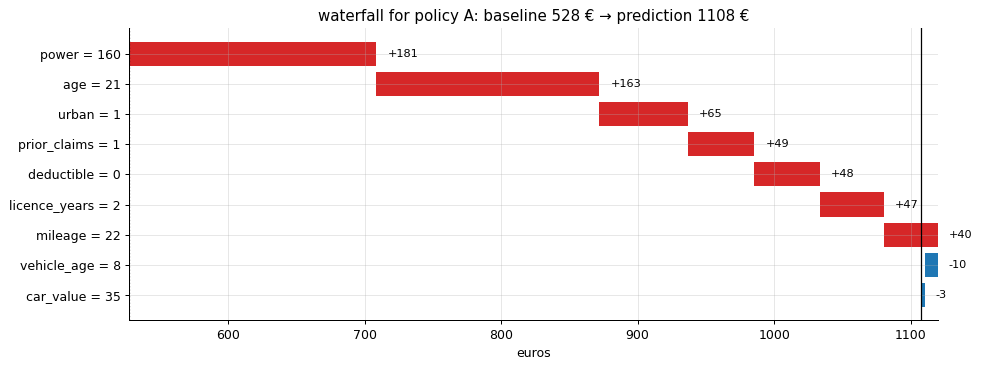

In [26]:
order_A = np.argsort(-np.abs(phi_A))
fig, ax = plt.subplots(figsize=(11, 4.2))
cum = v_A[0]
for r, j in enumerate(order_A):
    ax.barh(r, phi_A[j], left=cum, color="tab:red" if phi_A[j] > 0 else "tab:blue")
    ax.text(max(cum, cum + phi_A[j]) + 8, r, f"{phi_A[j]:+.0f}", va="center", fontsize=9)
    cum += phi_A[j]
ax.set_yticks(range(M)); ax.set_yticklabels([f"{FEATS[j]} = {policy_A[j]:g}" for j in order_A]); ax.invert_yaxis()
ax.axvline(v_A[0], color="k", ls=":", lw=1); ax.axvline(f_A, color="k", lw=1)
ax.set_xlabel("euros"); ax.set_title(f"waterfall for policy A: baseline {v_A[0]:.0f} € → prediction {f_A:.0f} €")
plt.tight_layout(); plt.show()

**Things to notice.**
- 2,000 policies in under a minute, and the additivity check holds for each of them to $5\times10^{-13}$.
- Global ranking by mean $\lvert\text{SHAP}\rvert$: `licence_years` 71.1 €, `urban` 54.9, `power` 52.1, `mileage` 42.6, `age` 40.5, `deductible` 36.6, `prior_claims` 32.2, then `car_value` 5.9 and `vehicle_age` 4.3. Permutation importance ranks `power` and `age` higher and `urban` lower. They measure different things: mean $\lvert\text{SHAP}\rvert$ is how much a feature moves the predictions; permutation is how much the error grows without it. A binary feature with a 45/55 split, like `urban`, moves every prediction by about ±55 €.
- **Beeswarm**: high deductibles (red) push the cost down, one or more past claims push it up by 50 € or more, a high `licence_years` (red) lowers it slightly while the few novices (blue) get up to about +300 €.
- **Dependence plot**: the SHAP value of `power` rises with power, and above 100 kW the drivers under 25 (orange) lie above the others. The vertical spread at a given power is the interaction.
- **Waterfall** for policy A: 528 € → power +181 → age +163 → urban +65 → prior claims +49 → deductible 0: +48 → licence +47 → mileage +40 → vehicle age −10 → car value −3 = 1,108 €. This is the format to show a customer or an underwriter.

## 8. LIME and its instability

**LIME** (Ribeiro, Singh and Guestrin, 2016) explains one prediction with a linear model that is only asked to be right *near* $\mathbf{x}$:

$$g = \arg\min_{g\ \text{linear}}\ \sum_{k} \pi_{\mathbf{x}}(\mathbf{z}_k)\,\big(f(\mathbf{z}_k) - g(\mathbf{z}_k)\big)^2 + \alpha\lVert\boldsymbol\beta\rVert^2, \qquad \pi_{\mathbf{x}}(\mathbf{z}) = e^{-\lVert\mathbf{z} - \mathbf{x}\rVert^2/\sigma^2}.$$

Recipe: (1) draw perturbed policies $\mathbf{z}_k$ around $\mathbf{x}$ (here: Gaussian noise of one standard deviation per feature, discrete features rounded to valid levels); (2) predict them with the black box; (3) weight them by proximity; (4) fit a weighted ridge regression. The slopes of $g$ are the explanation.

Two choices are left to the user: the **kernel width** $\sigma$ (what "near" means) and the **number of samples**. We compare the slopes with the true local slopes of $\mu$ at policy A. (The `lime` package samples from the training distribution and discretises features by quartiles by default; the issues below are the same.)

In [27]:
LO, HI = X_tr.min(0), X_tr.max(0)
LEVELS = {J["urban"]: np.array([0., 1.]), J["vehicle_age"]: np.arange(20.),
          J["deductible"]: np.array([0., 250., 500., 1000.]), J["prior_claims"]: np.arange(5.)}

def lime_explain(predict, x, n_samples=1000, width=2.0, seed=0, alpha=1e-3):
    """LIME from scratch: weighted ridge on standardised offsets. Returns slopes in euros per unit."""
    rng = np.random.default_rng(seed)
    Z = np.clip(x + scale * rng.normal(size=(n_samples, M)), LO, HI)
    for j, lev in LEVELS.items():
        Z[:, j] = lev[np.abs(Z[:, [j]] - lev).argmin(1)]
    D = (Z - x) / scale
    w = np.exp(-(D ** 2).sum(1) / width ** 2)
    A = np.column_stack([np.ones(n_samples), D])
    P = alpha * np.eye(M + 1); P[0, 0] = 0
    coef = np.linalg.solve(A.T @ (w[:, None] * A) + P, A.T @ (w * predict(Z)))
    return coef[1:] / scale, (w.sum() ** 2) / (w ** 2).sum()          # slopes, effective sample size

h = 1e-3 * scale
true_slope = np.array([(true_cost((policy_A + h[j] * np.eye(M)[j])[None]) - true_cost((policy_A - h[j] * np.eye(M)[j])[None]))[0] / (2 * h[j]) for j in range(M)])
widths = [0.5, 0.75, 1, 1.5, 2, 3, 5, 10]
lime_w = {s: np.array([lime_explain(hgb.predict, policy_A, 1000, s, seed)[0] for seed in range(20)]) for s in widths}
ess = {s: lime_explain(hgb.predict, policy_A, 1000, s, 0)[1] for s in widths}
print(f"{'feature':14s} {'true slope':>11s} " + " ".join(f"σ={s:<5g}" for s in [0.75, 2, 10]))
for j, name in enumerate(FEATS):
    print(f"{name:14s} {true_slope[j]:11.2f} " + " ".join(f"{lime_w[s][:, j].mean():7.2f}" for s in [0.75, 2, 10]))
print("effective number of samples (of 1000):", {s: round(e) for s, e in ess.items()})

stab = {n: np.array([lime_explain(hgb.predict, policy_A, n, 1.0, seed)[0] for seed in range(20)]) for n in [200, 5000]}
for n, C in stab.items():
    top3 = [tuple(sorted(np.argsort(-np.abs(c * scale))[:3])) for c in C]
    print(f"n = {n:4d}: std over 20 seeds of the licence_years slope {C[:, 1].std():.2f} €/year, of the power slope {C[:, 2].std():.2f} €/kW; "
          f"{len(set(top3))} different top-3 feature sets")

feature         true slope σ=0.75  σ=2     σ=10   
age                 -25.27  -24.34  -14.25  -11.42
licence_years       -55.18  -29.90  -16.45  -13.01
power                 5.80    4.53    3.37    3.05
car_value             0.00   -0.70    0.35    0.75
mileage               8.00    6.86    7.99    7.76
urban               120.00  140.48  131.91  126.49
vehicle_age           0.00    0.28    0.23    0.37
deductible           -0.15   -0.21   -0.12   -0.10
prior_claims         90.00   59.66   70.20   68.79
effective number of samples (of 1000): {0.5: 11, 0.75: 41, 1: 110, 1.5: 343, 2: 595, 3: 866, 5: 978, 10: 998}


n =  200: std over 20 seeds of the licence_years slope 3.55 €/year, of the power slope 1.24 €/kW; 4 different top-3 feature sets
n = 5000: std over 20 seeds of the licence_years slope 0.60 €/year, of the power slope 0.23 €/kW; 1 different top-3 feature sets


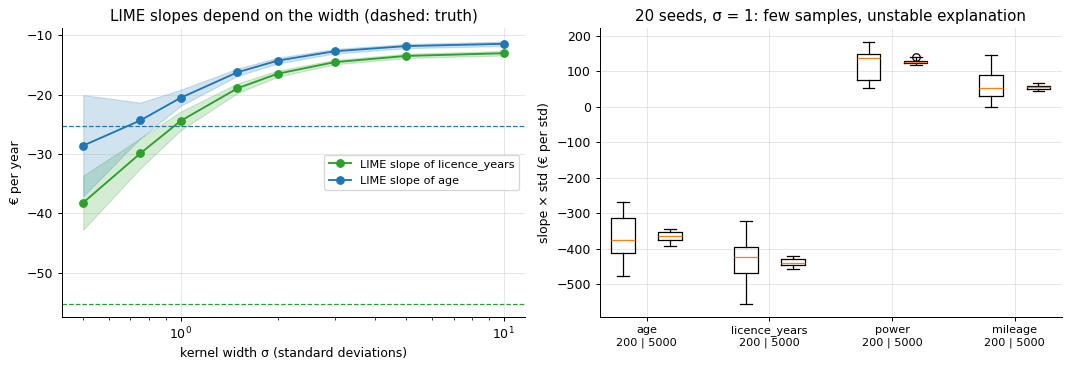

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for j, c in [(J["licence_years"], "tab:green"), (J["age"], "tab:blue")]:
    mu_ = np.array([lime_w[s][:, j].mean() for s in widths]); sd_ = np.array([lime_w[s][:, j].std() for s in widths])
    axes[0].plot(widths, mu_, "o-", color=c, label=f"LIME slope of {FEATS[j]}")
    axes[0].fill_between(widths, mu_ - sd_, mu_ + sd_, color=c, alpha=0.2)
    axes[0].axhline(true_slope[j], color=c, ls="--", lw=1)
axes[0].set_xscale("log"); axes[0].set_xlabel("kernel width σ (standard deviations)"); axes[0].set_ylabel("€ per year")
axes[0].set_title("LIME slopes depend on the width (dashed: truth)"); axes[0].legend(fontsize=9)
show_j = [J["age"], J["licence_years"], J["power"], J["mileage"]]
data = [stab[n][:, j] * scale[j] for j in show_j for n in [200, 5000]]
axes[1].boxplot(data, positions=np.arange(len(data)) + np.repeat(np.arange(len(show_j)), 2) * 0.6)
axes[1].set_xticks(np.arange(0, 2 * len(show_j), 2) + 0.5 + np.arange(len(show_j)) * 0.6)
axes[1].set_xticklabels([f"{FEATS[j]}\n200 | 5000" for j in show_j], fontsize=9)
axes[1].set_ylabel("slope × std (€ per std)"); axes[1].set_title("20 seeds, σ = 1: few samples, unstable explanation")
plt.tight_layout(); plt.show()

**What just happened?**
- **Kernel width.** With $\sigma = 0.75$ (41 effective samples out of 1,000) LIME finds an age slope of $-24.3$ €/year (truth $-25.3$) and a power slope of 4.53 €/kW (truth 5.8, and the model itself underestimates it). With $\sigma = 10$, all samples count equally and the slopes shrink to $-11.4$ and 3.05: a wide kernel describes a regional average, not the neighbourhood of policy A. The youth and novice effects are curved, so there is no single right width, and LIME does not tell you which one to use.
- **Instability.** At $\sigma = 1$ with 200 samples, 20 seeds give a `licence_years` slope with a standard deviation of 3.55 €/year, a power slope with 1.24 €/kW, and **4 different top-3 feature sets**. With 5,000 samples: 0.60, 0.23 and a single top-3 set. Same model, same policy, same method: a different explanation for a different random seed. Always check stability before showing a LIME explanation.
- LIME's slopes for discrete features are rough (prior claims: 60 to 70 € instead of 90 €): rounding the perturbations to valid levels makes the neighbourhood lumpy.

## 9. Neural networks: saliency, Integrated Gradients, Grad-CAM and a sanity check

A neural network is differentiable, so the gradient of the output with respect to the **input** is one backward pass away (the same backpropagation as for the weights).

- **Saliency** (Simonyan et al., 2014): $\lvert\partial f_c/\partial x_j\rvert$, how much the class score $f_c$ reacts to a small change of pixel $j$.
- **Gradient × input**: $x_j\,\partial f_c/\partial x_j$, a first-order estimate of the contribution of pixel $j$.
- **Integrated Gradients** (Sundararajan, Taly and Yan, 2017): integrate the gradient along the straight path from a **baseline** $\mathbf{x}'$ (here a black image) to $\mathbf{x}$:
$$\mathrm{IG}_j(\mathbf{x}) = (x_j - x'_j)\int_0^1 \frac{\partial f_c\big(\mathbf{x}' + \alpha(\mathbf{x} - \mathbf{x}')\big)}{\partial x_j}\,d\alpha \approx (x_j - x'_j)\,\frac1m\sum_{k=1}^m \frac{\partial f_c\big(\mathbf{x}' + \tfrac{k-1/2}{m}(\mathbf{x} - \mathbf{x}')\big)}{\partial x_j}.$$
  By the fundamental theorem of calculus for line integrals, $\sum_j \mathrm{IG}_j = f_c(\mathbf{x}) - f_c(\mathbf{x}')$: **completeness**, the efficiency axiom of Shapley values. Gradient × input has no such guarantee: where the network saturates the gradient is small although the feature matters.
- **Grad-CAM** (Selvaraju et al., 2017), for CNNs: average the gradient of $f_c$ over each feature map $A^k$ of the last convolutional layer to get its weight $\alpha_k$, and show $\mathrm{ReLU}\big(\sum_k\alpha_kA^k\big)$, upsampled to the image size. Coarse but class-specific.

We train a small CNN on MNIST (2 epochs, about 40 s on a CPU).

In [29]:
mnist_tr = torchvision.datasets.MNIST("data", train=True, download=True)
mnist_te = torchvision.datasets.MNIST("data", train=False, download=True)
Xm_tr = mnist_tr.data.float().div(255).unsqueeze(1); ym_tr = mnist_tr.targets
Xm_te = mnist_te.data.float().div(255).unsqueeze(1); ym_te = mnist_te.targets

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1, self.conv2 = nn.Conv2d(1, 16, 3, padding=1), nn.Conv2d(16, 32, 3, padding=1)
        self.fc1, self.fc2 = nn.Linear(32 * 7 * 7, 64), nn.Linear(64, 10)
    def features(self, x):                       # last convolutional feature maps A^k (32 x 14 x 14), for Grad-CAM
        return F.relu(self.conv2(F.max_pool2d(F.relu(self.conv1(x)), 2)))
    def head(self, A):
        return self.fc2(F.relu(self.fc1(F.max_pool2d(A, 2).flatten(1))))
    def forward(self, x):
        return self.head(self.features(x))

torch.manual_seed(0)
cnn = SmallCNN().to(device)
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
t0 = time.time()
for epoch in range(2):
    perm = torch.randperm(len(Xm_tr))
    for i in range(0, len(perm), 128):
        b = perm[i:i + 128]
        opt.zero_grad(); F.cross_entropy(cnn(Xm_tr[b].to(device)), ym_tr[b].to(device)).backward(); opt.step()
cnn.eval()
with torch.no_grad():
    acc = (cnn(Xm_te.to(device)).argmax(1).cpu() == ym_te).float().mean().item()
print(f"test accuracy {acc:.4f} after 2 epochs ({time.time() - t0:.0f} s)")

test accuracy 0.9840 after 2 epochs (9 s)


In [30]:
def grad_input(model, x, c):
    """Gradient of the class scores f_c with respect to a batch of inputs x (one class per image)."""
    x = x.clone().requires_grad_(True)
    model(x).gather(1, c[:, None]).sum().backward()
    return x.grad

def integrated_gradients(model, x, c, steps=64):
    """IG with a black baseline and the midpoint rule; x: (B, 1, 28, 28)."""
    total = torch.zeros_like(x)
    for k in range(steps):
        total += grad_input(model, (k + 0.5) / steps * x, c)
    return x * total / steps

def grad_cam(model, x, c):
    A = model.features(x).detach().requires_grad_(True)
    model.head(A).gather(1, c[:, None]).sum().backward()
    alpha = A.grad.mean((2, 3), keepdim=True)
    cam = F.relu((alpha * A).sum(1, keepdim=True))
    return F.interpolate(cam, size=28, mode="bilinear", align_corners=False).detach()

def all_maps(model, x, c):
    g = grad_input(model, x, c)
    return {"saliency |∇f|": g.abs(), "gradient × input": x * g, "Integrated Gradients": integrated_gradients(model, x, c),
            "Grad-CAM": grad_cam(model, x, c)}

xs = Xm_te[:20].to(device)
with torch.no_grad():
    cs = cnn(xs).argmax(1)
    gap_f = (cnn(xs).gather(1, cs[:, None]) - cnn(torch.zeros_like(xs)).gather(1, cs[:, None])).squeeze(1)
for m in [4, 16, 64, 256]:
    ig = integrated_gradients(cnn, xs, cs, steps=m)
    rel = ((ig.sum((1, 2, 3)) - gap_f).abs() / gap_f.abs()).mean().item()
    print(f"IG with m = {m:3d} steps: mean relative completeness error {rel:.2%}")
gi = (xs * grad_input(cnn, xs, cs)).sum((1, 2, 3))
print(f"gradient × input: mean relative error {((gi - gap_f).abs() / gap_f.abs()).mean().item():.1%}  (no completeness)")
assert rel < 0.01

IG with m =   4 steps: mean relative completeness error 3.05%
IG with m =  16 steps: mean relative completeness error 0.47%
IG with m =  64 steps: mean relative completeness error 0.11%


IG with m = 256 steps: mean relative completeness error 0.02%
gradient × input: mean relative error 3.5%  (no completeness)


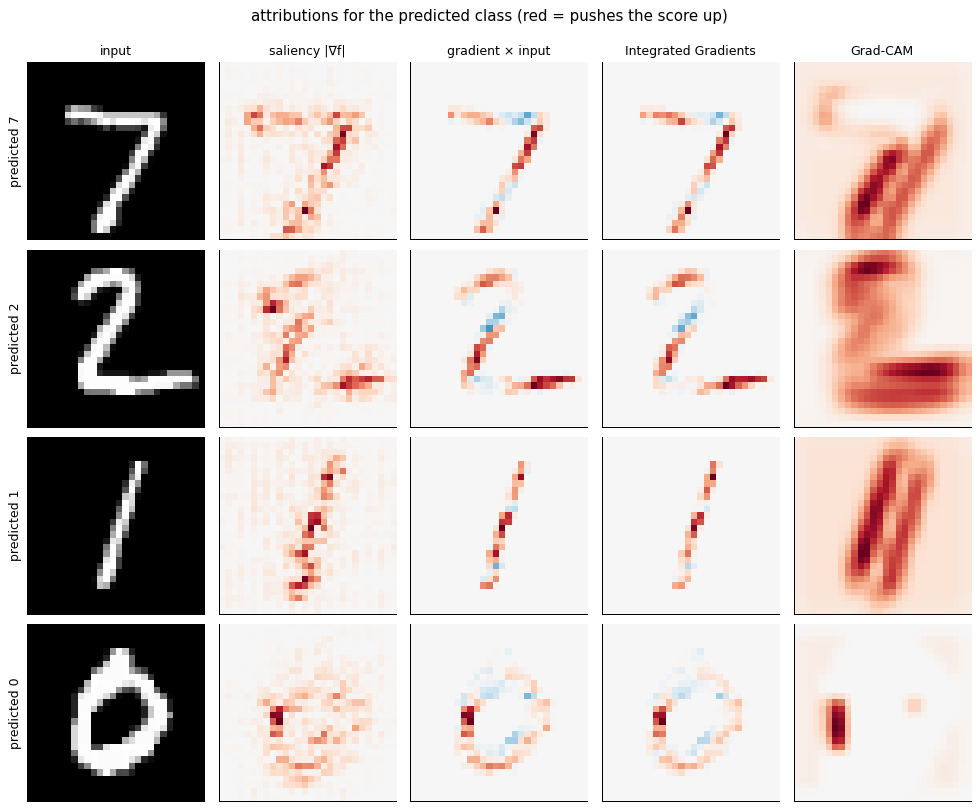

In [31]:
show_idx = [0, 1, 2, 3]
x4 = Xm_te[show_idx].to(device)
with torch.no_grad():
    c4 = cnn(x4).argmax(1)
maps = all_maps(cnn, x4, c4)
fig, axes = plt.subplots(len(show_idx), 5, figsize=(11, 9))
for r in range(len(show_idx)):
    axes[r, 0].imshow(x4[r, 0].cpu(), cmap="gray"); axes[r, 0].set_ylabel(f"predicted {c4[r].item()}")
    for k, (name, mp) in enumerate(maps.items()):
        a = mp[r, 0].cpu().numpy(); lim = np.abs(a).max() + 1e-12
        axes[r, k + 1].imshow(a, cmap="RdBu_r", vmin=-lim, vmax=lim)
        if r == 0: axes[r, k + 1].set_title(name, fontsize=10)
axes[0, 0].set_title("input", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle("attributions for the predicted class (red = pushes the score up)", y=0.995)
plt.tight_layout(); plt.show()

**What just happened?**
- The small CNN reaches 98.40% test accuracy after 2 epochs.
- **Completeness.** The relative gap between $\sum_j\mathrm{IG}_j$ and $f_c(\mathbf{x}) - f_c(\mathbf{x}')$ is 3.05% with $m = 4$ steps, 0.47% with 16, 0.11% with 64 and 0.02% with 256 (the error shrinks 4 to 6 times each time $m$ is multiplied by 4). Gradient × input is off by 3.5%: a ReLU network is piecewise linear, so it is close here; for saturating networks it can be far off (slides).
- **The maps.** Saliency is noisy and also lights up background pixels: changing them *would* change the score. Gradient × input and IG are exactly zero on the black background, because $x_j - x'_j = 0$ there, and follow the strokes. Grad-CAM is a coarse 14×14 blob, upsampled, over the parts of the digit that drive the class.

**Sanity check** (Adebayo et al., 2018). An explanation of *the model* must change when the model changes. The **cascading randomisation test** re-initialises the layers one by one, from the output layer down to the first convolution, and compares the new maps with the original ones by the Spearman rank correlation of the absolute attributions (over 50 test images, for the class predicted by the trained network). A method whose maps survive randomisation is describing the input, not the model.

In [32]:
import copy
xs50 = Xm_te[:50].to(device)
with torch.no_grad():
    c50 = cnn(xs50).argmax(1)

digit = (xs50 > 0.1).flatten(1).cpu().numpy()            # the pixels of the digit itself

def rank_corr(a, b):
    return spearmanr(a, b)[0] if a.std() > 0 and b.std() > 0 else 0.0   # a constant map has no ranking

def map_corr(maps_a, maps_b, pixels):
    """Mean Spearman correlation of |attributions| over 50 images; pixels = 'all' or 'digit'."""
    out = {}
    for name in maps_a:
        a = maps_a[name].abs().flatten(1).cpu().numpy(); b = maps_b[name].abs().flatten(1).cpu().numpy()
        out[name] = np.mean([rank_corr(a[i], b[i]) if pixels == "all" else rank_corr(a[i][digit[i]], b[i][digit[i]])
                             for i in range(len(a))])
    return out

ref = all_maps(cnn, xs50, c50)
stages = ["trained"]; corr = {p: {name: [1.0] for name in ref} for p in ["all", "digit"]}
rand_model = copy.deepcopy(cnn)
torch.manual_seed(1)
for layer in ["fc2", "fc1", "conv2", "conv1"]:
    getattr(rand_model, layer).reset_parameters()
    new = all_maps(rand_model, xs50, c50); stages.append("+" + layer)
    for p in corr:
        cc = map_corr(ref, new, p)
        for name in ref:
            corr[p][name].append(cc[name])
for p in corr:
    print(f"rank correlation with the trained maps, {p} pixels:")
    for name in ref:
        print(f"  {name:22s}", "  ".join(f"{s}: {c:5.2f}" for s, c in zip(stages, corr[p][name])))
maps_rand = all_maps(rand_model, x4, c4)

rank correlation with the trained maps, all pixels:
  saliency |∇f|          trained:  1.00  +fc2:  0.66  +fc1:  0.54  +conv2:  0.40  +conv1:  0.15
  gradient × input       trained:  1.00  +fc2:  0.99  +fc1:  0.99  +conv2:  0.99  +conv1:  0.99
  Integrated Gradients   trained:  1.00  +fc2:  0.99  +fc1:  0.99  +conv2:  0.99  +conv1:  0.99
  Grad-CAM               trained:  1.00  +fc2:  0.49  +fc1:  0.46  +conv2:  0.20  +conv1:  0.09
rank correlation with the trained maps, digit pixels:
  saliency |∇f|          trained:  1.00  +fc2:  0.28  +fc1:  0.10  +conv2:  0.04  +conv1: -0.01
  gradient × input       trained:  1.00  +fc2:  0.49  +fc1:  0.36  +conv2:  0.33  +conv1:  0.27
  Integrated Gradients   trained:  1.00  +fc2:  0.51  +fc1:  0.37  +conv2:  0.33  +conv1:  0.28
  Grad-CAM               trained:  1.00  +fc2:  0.25  +fc1:  0.31  +conv2: -0.01  +conv1:  0.04


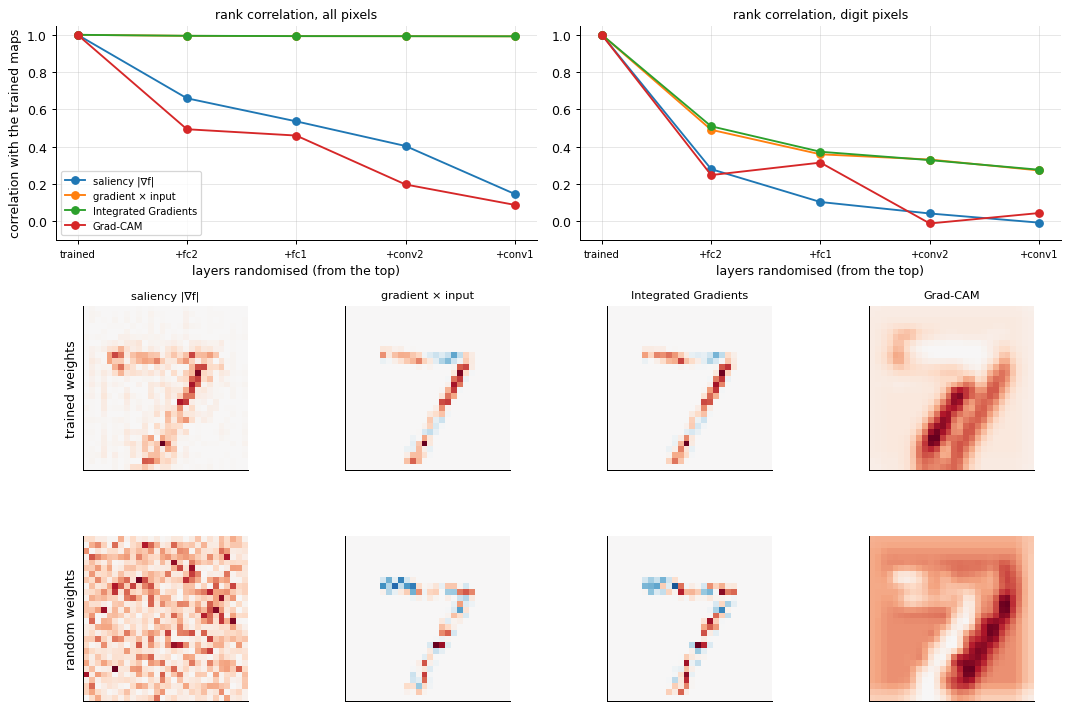

In [33]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 4, height_ratios=[1.3, 1, 1])
for col, p in enumerate(["all", "digit"]):
    ax = fig.add_subplot(gs[0, 2 * col:2 * col + 2])
    for name in corr[p]:
        ax.plot(range(len(stages)), corr[p][name], "o-", label=name)
    ax.set_xticks(range(len(stages))); ax.set_xticklabels(stages, fontsize=8); ax.set_ylim(-0.1, 1.05)
    ax.set_xlabel("layers randomised (from the top)"); ax.set_title(f"rank correlation, {p} pixels", fontsize=10)
    if col == 0: ax.legend(fontsize=8); ax.set_ylabel("correlation with the trained maps")
for k, name in enumerate(maps):
    for r, (mp, lab) in enumerate([(maps, "trained"), (maps_rand, "random")]):
        a = mp[name][0, 0].cpu().numpy(); lim = np.abs(a).max() + 1e-12
        axi = fig.add_subplot(gs[r + 1, k]); axi.imshow(a, cmap="RdBu_r", vmin=-lim, vmax=lim)
        axi.set_xticks([]); axi.set_yticks([]); axi.grid(False)
        if r == 0: axi.set_title(name, fontsize=9)
        if k == 0: axi.set_ylabel(f"{lab} weights")
plt.tight_layout(); plt.show()

**Interpretation.**
- **All pixels.** After randomising every layer, saliency keeps a rank correlation of 0.15 with the trained maps and Grad-CAM 0.09: they depend on the weights. Gradient × input and IG stay at **0.99**: the black background is exactly zero in the trained *and* in the random maps, so most of the ranking is fixed by the input, whatever the network.
- **Digit pixels only.** Saliency falls to $-0.01$ and Grad-CAM to 0.04, but gradient × input and IG keep 0.27 and 0.28: even inside the digit, part of the map is the brightness of the pixels times a random gradient.
- A map that looks like the digit is therefore not evidence that the model looks at the digit. Before trusting an attribution method on a new model, run the randomisation test (and its companion, training on shuffled labels).

## 10. Counterfactual explanations and a fairness check

A **counterfactual explanation** (Wachter, Mittelstadt and Russell, 2017) answers "what is the smallest change that would change the decision?". Our fictional insurer refers a policy to manual underwriting when the predicted cost exceeds $\tau = 900$ €. Policy A is referred. As an optimisation problem:

$$\mathbf{x}^{\mathrm{cf}} = \arg\min_{\mathbf{x}'}\ \lambda\,\big(f(\mathbf{x}') - \tau\big)_+^2 + d(\mathbf{x}', \mathbf{x}) \quad\text{subject to } \mathbf{x}' \text{ plausible and } x'_j = x_j \text{ for non-actionable } j.$$

- the distance $d$ is measured in standard deviations; the **L1** norm $\sum_j\lvert x'_j - x_j\rvert/s_j$ favours **sparse** changes (few features), the L2 norm spreads the change;
- **actionability**: age, licence years, past claims cannot be changed; here only `power` (choose another car), `mileage` and `deductible` may move, within the observed ranges;
- $\lambda$ is increased until the decision flips (Wachter's recipe).

For a differentiable model the problem is solved by gradient descent on $\mathbf{x}'$. We train a small MLP regressor on the standardised features for that, then compare with a **model-agnostic grid search** on the gradient-boosting model.

In [34]:
mean_x, std_x = X_tr.mean(0), X_tr.std(0); y_m, y_s = y_tr.mean(), y_tr.std()
torch.manual_seed(0)
mlp = nn.Sequential(nn.Linear(M, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
Xt = torch.tensor((X_tr - mean_x) / std_x, dtype=torch.float32); yt = torch.tensor((y_tr - y_m) / y_s, dtype=torch.float32)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-2, weight_decay=1e-3)
for step in range(100):                                    # 100 full-batch steps: longer training overfits the noise
    opt.zero_grad(); F.mse_loss(mlp(Xt).squeeze(1), yt).backward(); opt.step()
mlp.eval()
def mlp_predict(X):
    with torch.no_grad():
        return mlp(torch.tensor((np.atleast_2d(X) - mean_x) / std_x, dtype=torch.float32)).squeeze(1).numpy() * y_s + y_m
print(f"MLP: test R² {r2_score(y_te, mlp_predict(X_te)):.3f}, RMSE to truth {rmse(mlp_predict(X_te), mu_te):.1f} €")
TAU = 900
print(f"policy A: MLP {mlp_predict(policy_A)[0]:.0f} €, gradient boosting {hgb.predict(policy_A[None])[0]:.0f} €, truth {true_cost(policy_A[None])[0]:.0f} €  -> referred (τ = {TAU} €)")

MLP: test R² 0.692, RMSE to truth 37.4 €
policy A: MLP 1450 €, gradient boosting 1108 €, truth 1284 €  -> referred (τ = 900 €)


In [35]:
ACTION = [J["power"], J["mileage"], J["deductible"]]
z_lo = torch.tensor((LO - mean_x) / std_x, dtype=torch.float32); z_hi = torch.tensor((HI - mean_x) / std_x, dtype=torch.float32)

def counterfactual_gd(x, norm="l1", steps=400, lr=0.05):
    """Wachter-style search on the MLP, in standardised units; only the ACTION features move."""
    z0 = torch.tensor((x - mean_x) / std_x, dtype=torch.float32)
    act = torch.zeros(M); act[ACTION] = 1
    for lam in [1, 2, 4, 8, 16, 32, 64, 128, 256]:
        z = z0.clone().requires_grad_(True); opt = torch.optim.Adam([z], lr=lr); path = []
        for t in range(steps):
            zz = z0 + act * (z - z0)
            over = F.relu(mlp(zz[None])[0, 0] * y_s + y_m - (TAU - 5)) / 100        # hundreds of euros above τ − 5
            dist = (zz - z0).abs().sum() if norm == "l1" else ((zz - z0) ** 2).sum()
            opt.zero_grad(); (lam * over ** 2 + dist).backward(); opt.step()
            with torch.no_grad():
                z.copy_(torch.maximum(torch.minimum(z, z_hi), z_lo))
            path.append((z0 + act * (z.detach() - z0)).numpy() * std_x + mean_x)
        x_cf = path[-1]
        if mlp_predict(x_cf)[0] <= TAU:
            return x_cf, np.array(path), lam
    return x_cf, np.array(path), lam

def describe(x_cf):
    return ", ".join(f"{FEATS[j]} {policy_A[j]:g} → {x_cf[j]:.0f}" for j in ACTION if abs(x_cf[j] - policy_A[j]) > 0.5)

cf = {}
for norm in ["l1", "l2"]:
    x_cf, path, lam = counterfactual_gd(policy_A, norm)
    cf[norm] = (x_cf, path)
    d1 = np.sum(np.abs(x_cf - policy_A) / std_x)
    print(f"{norm.upper()}: λ = {lam:3d}, MLP {mlp_predict(x_cf)[0]:.0f} €, L1 distance {d1:.2f} std:  {describe(x_cf)}")
x1 = cf["l1"][0].copy(); x1[J["deductible"]] = [0, 250, 500, 1000][np.argmin(np.abs(np.array([0, 250, 500, 1000]) - x1[J["deductible"]]))]
print(f"L1 counterfactual with the deductible rounded to a valid level: MLP {mlp_predict(x1)[0]:.0f} €, truth {true_cost(x1[None])[0]:.0f} €")

# model-agnostic: exhaustive grid over the actionable features, on the gradient-boosting model
P_, K_, D_ = np.meshgrid(np.arange(45, 251, 5.), np.arange(2, 51, 1.), np.array([0., 250., 500., 1000.]), indexing="ij")
cand = np.tile(policy_A, (P_.size, 1)); cand[:, J["power"]], cand[:, J["mileage"]], cand[:, J["deductible"]] = P_.ravel(), K_.ravel(), D_.ravel()
cost = np.abs(cand - policy_A) @ (1 / std_x); ok = hgb.predict(cand) <= TAU
best = cand[ok][np.argmin(cost[ok])]
print(f"grid search on gradient boosting ({len(cand)} candidates, {ok.mean():.0%} accepted): {describe(best)} "
      f"-> {hgb.predict(best[None])[0]:.0f} €, L1 distance {cost[ok].min():.2f} std")
okm = ok & (cand[:, J["power"]] == policy_A[J["power"]])
best_km = cand[okm][np.argmin(cost[okm])] if okm.any() else None
print("keeping the same car (power fixed):", describe(best_km) if best_km is not None else "no solution",
      f"-> {hgb.predict(best_km[None])[0]:.0f} €" if best_km is not None else "")

L1: λ =   8, MLP 899 €, L1 distance 2.60 std:  power 160 → 100, mileage 22 → 17


L2: λ =  16, MLP 899 €, L1 distance 3.04 std:  power 160 → 105, mileage 22 → 16, deductible 0 → 159
L1 counterfactual with the deductible rounded to a valid level: MLP 899 €, truth 897 €
grid search on gradient boosting (8232 candidates, 36% accepted): power 160 → 110 -> 862 €, L1 distance 1.59 std
keeping the same car (power fixed): no solution 


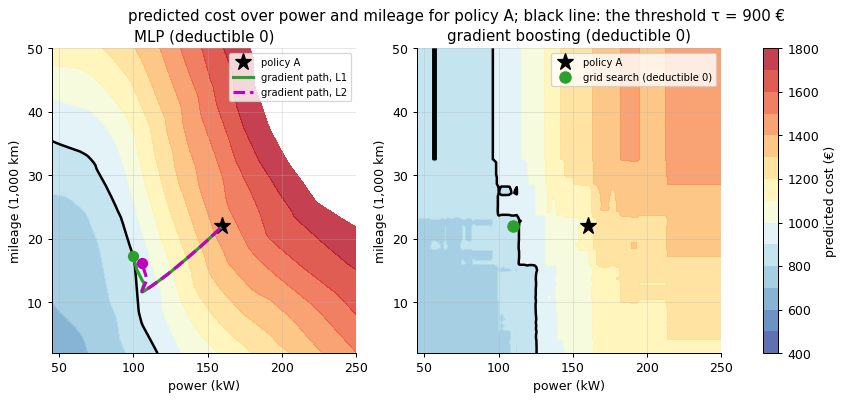

In [36]:
pp, kk = np.meshgrid(np.linspace(45, 250, 120), np.linspace(2, 50, 100))
G = np.tile(policy_A, (pp.size, 1)); G[:, J["power"]], G[:, J["mileage"]] = pp.ravel(), kk.ravel()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (name, pred) in zip(axes, [("MLP", mlp_predict), ("gradient boosting", hgb.predict)]):
    Zg = pred(G).reshape(pp.shape)
    cs_ = ax.contourf(pp, kk, Zg, levels=np.arange(400, 1801, 100), cmap="RdYlBu_r", alpha=0.8)
    ax.contour(pp, kk, Zg, levels=[TAU], colors="k", linewidths=2)
    ax.plot(policy_A[2], policy_A[4], "k*", ms=14, label="policy A")
    ax.set_xlabel("power (kW)"); ax.set_ylabel("mileage (1,000 km)"); ax.set_title(f"{name} (deductible 0)")
for norm, c, ls in [("l1", "tab:green", "-"), ("l2", "m", "--")]:
    pth = cf[norm][1]; axes[0].plot(pth[:, 2], pth[:, 4], color=c, lw=2.5, ls=ls, label=f"gradient path, {norm.upper()}")
    axes[0].plot(pth[-1, 2], pth[-1, 4], "o", color=c, ms=8)
axes[1].plot(best[2], best[4], "o", color="tab:green", ms=9, label=f"grid search (deductible {best[7]:.0f})")
for ax in axes:
    ax.legend(loc="upper right", fontsize=8)
plt.colorbar(cs_, ax=axes, label="predicted cost (€)")
fig.suptitle("predicted cost over power and mileage for policy A; black line: the threshold τ = 900 €")
plt.show()

**What just happened?**
- The MLP ($R^2 = 0.692$, 37.4 € from the truth) quotes 1,450 € for policy A; gradient boosting 1,108 €; the truth is 1,284 €. Three models, three prices, three different explanations.
- **L1 counterfactual** ($\lambda = 8$): power 160 → 100 kW and mileage 22 → 17 thousand km bring the MLP to 899 €, at a distance of 2.60 standard deviations. The deductible did not move. **L2** ($\lambda = 16$): power 105 kW, mileage 16, deductible 159 €: all three features change, and 159 € is not a deductible the insurer offers, so plausibility needs rounding or a discrete search. For the L1 counterfactual the true cost is 897 €, so this one also holds in the simulated world; in general a counterfactual only describes the model.
- **Grid search** on gradient boosting (8,232 candidates, every one valid by construction): a car of 110 kW, nothing else changed, gives 862 € at 1.59 standard deviations. Keeping the same car, no combination of mileage and deductible gets below 900 €. That is useful **recourse**: "with a car of at most 110 kW the policy would be accepted without referral". Telling the driver to be older is not.

**Fairness check by group.** The sex of the driver is not a model input. That does not make the predictions independent of it: a feature correlated with sex can carry it (**proxy discrimination**). Two quick checks: compare the average prediction by group, and decompose the gap with the SHAP values. Because SHAP values are additive and share the same baseline, the gap of the mean predictions between two groups is *exactly* the sum over features of the gaps of the mean SHAP values.

mean prediction: men 517 €, women 496 € (gap +21 €); truth gap +22 €
test set: gap +21.5 € = sum of the SHAP gaps +21.5 €
  power           +28.7 €
  urban            -3.0 €
  licence_years    -2.2 €
  deductible       -1.6 €


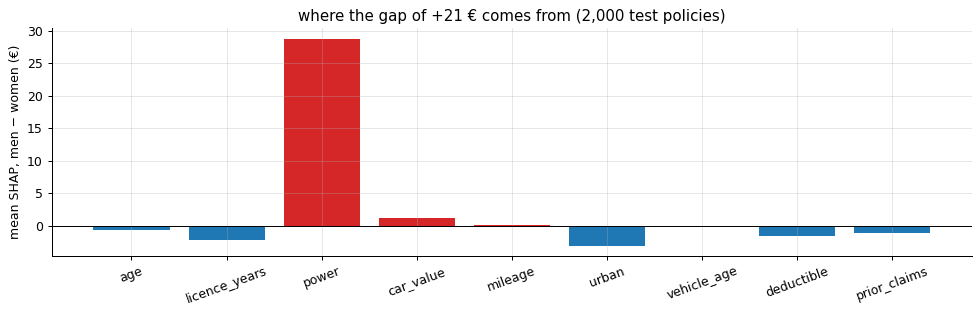

In [37]:
pred_te = hgb.predict(X_te)
print(f"mean prediction: men {pred_te[male_te].mean():.0f} €, women {pred_te[~male_te].mean():.0f} € "
      f"(gap {pred_te[male_te].mean() - pred_te[~male_te].mean():+.0f} €); truth gap {mu_te[male_te].mean() - mu_te[~male_te].mean():+.0f} €")
dphi = PHI[male_te].mean(0) - PHI[~male_te].mean(0)
dpred = pred_te[male_te].mean() - pred_te[~male_te].mean()
assert np.isclose(dphi.sum(), dpred)
print(f"test set: gap {dpred:+.1f} € = sum of the SHAP gaps {dphi.sum():+.1f} €")
for j in np.argsort(-np.abs(dphi))[:4]:
    print(f"  {FEATS[j]:14s} {dphi[j]:+6.1f} €")
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(xx, dphi, color=["tab:red" if v > 0 else "tab:blue" for v in dphi])
ax.axhline(0, color="k", lw=0.8); ax.set_xticks(xx); ax.set_xticklabels(FEATS, rotation=20)
ax.set_ylabel("mean SHAP, men − women (€)"); ax.set_title(f"where the gap of {dpred:+.0f} € comes from (2,000 test policies)")
plt.tight_layout(); plt.show()

**Interpretation.**
- The model predicts 21 € more for men than for women (517 € against 496 €), although sex is not an input; the truth gives 22 €. The SHAP decomposition adds up exactly to the gap (21.5 €) and points at one feature: `power`, +28.7 €, because men drive 14 kW more powerful cars in this portfolio. The other features contribute a few euros of both signs (sample differences between the two groups of the test set).
- Here the channel is a genuine risk factor: `power` has a causal effect in the simulation. Had the gap come through a feature with no effect of its own (`car_value`, say), it would be **proxy discrimination**. The explanation shows *where* a gap comes from; whether it is acceptable is a legal and ethical decision (the EU Test-Achats ruling of 2011 imposed sex-neutral premiums from 21 December 2012).
- Explanations are not causal claims: SHAP says how the model uses `power`, not what would happen to the claims if a driver changed car. That question needs causal inference (Extra 11).

In [38]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 1.4 min on cpu


## 11. Summary

- **Know what you ask.** Global (the whole model) or local (one prediction); model-specific or model-agnostic; interpretable by design or explained after the fact. On this portfolio a GAM was as accurate as gradient boosting ($R^2$ 0.698 for both, 32.5 € vs 38.0 € from the truth) and explains itself.
- **Impurity importance** is computed on training data and rewards columns that can fit noise: a random ID ranked above a +90 € risk factor. **Permutation importance** (test RMSE increase) put the ID at $-0.1$ €; ours matched scikit-learn to 0.71 €. With correlated features it measures reliance, not information: age 29.7 € by permutation, 3.2 € by drop-column.
- **PDP** $\mathrm{PD}_j(z) = \frac1n\sum_i f(z, \mathbf{x}_{i,-j})$, the mean of the **ICE** curves; ICE curves revealed the young × power interaction (3.92 vs 1.16 €/kW) that the PDP averages away (1.50). With correlated features the PDP evaluates impossible rows (85% at age 22) and flattened the youth effect (forest: 64 € instead of 244 €).
- **ALE** accumulates local differences within quantile bins: no extrapolation (forest: 139 €, boosting: 184 €, against PDP 64 € and 165 €). It cannot decide between near-duplicate features. A **global surrogate** tree of depth 3 reached a fidelity of 0.657.
- **Shapley values** $\phi_j = \sum_{S \not\ni j}\frac{|S|!(M-|S|-1)!}{M!}\big[v(S\cup\{j\}) - v(S)\big]$: the unique attribution with efficiency, symmetry, dummy and additivity. Toy example: 192.5 + 127.5 + 50 = 800 − 430. Policy A: 528 € + 580 € of SHAP values = 1,108 €.
- **Value function**: interventional $v(S) = \mathbb{E}[f(\mathbf{x}_S, \mathbf{X}_{\bar S})]$ is true to the model (`car_value` 0 €), conditional is true to the data (`car_value` 50.3 €).
- **KernelSHAP** = weighted least squares with the Shapley kernel; exact with all coalitions ($2\times10^{-13}$), 2.45 € error with 64 sampled coalitions. TreeSHAP is the fast exact algorithm for tree ensembles. Beeswarm, dependence and waterfall plots; additivity held for all 2,000 test policies.
- **LIME** fits a proximity-weighted linear model around $\mathbf{x}$: its answer depends on the kernel width (age slope $-24.3$ at $\sigma = 0.75$, $-11.4$ at $\sigma = 10$) and, with few samples, on the seed (4 different top-3 sets over 20 seeds).
- **Gradients**: saliency $\lvert\nabla_{\mathbf{x}}f_c\rvert$, gradient × input, **Integrated Gradients** $(x_j - x'_j)\int_0^1\partial_jf(\mathbf{x}' + \alpha(\mathbf{x} - \mathbf{x}'))\,d\alpha$ with completeness (0.02% error with 256 steps), Grad-CAM. **Sanity check**: after randomising all layers, gradient × input and IG kept a rank correlation of 0.99 (all pixels) and 0.28 (digit pixels): they partly show the input, not the model.
- **Counterfactuals**: the smallest actionable change that flips the decision. L1 is sparse (power 160 → 100 kW, mileage 22 → 17 on the MLP); a grid search on gradient boosting found "a car of 110 kW". Recourse must use actionable, plausible changes.
- **Fairness by group**: a 21 € gap between men and women without sex as an input, 28.7 € of it through `power`. Explanations locate a gap; they do not judge it, and they are not causal claims.

## Exercises

Try each one before opening the answer.

1. **Shapley by hand.** With the toy model and the same four background policies, compute the eight coalition values and the Shapley values for the policy $\mathbf{x} = (0, 150, 1)$ (not young). Check efficiency.
2. **The linear case.** Prove that for a linear model $f(\mathbf{x}) = \beta_0 + \sum_j\beta_jx_j$ and the interventional value function, $\phi_j = \beta_j\,(x_j - \mathbb{E}[X_j])$. What does the conditional value function give when $X_1$ and $X_2$ are perfectly correlated?
3. **PDP of an additive model.** Show that if $f(\mathbf{x}) = g_j(x_j) + h(\mathbf{x}_{-j})$ then $\mathrm{PD}_j(z) = g_j(z) + \text{const}$ and all ICE curves are parallel. What do non-parallel ICE curves prove?
4. **A duplicated column.** Add an exact copy of `licence_years` to the data and refit gradient boosting. What happens to the permutation importance and to the drop-column importance of `licence_years`? To its SHAP values?
5. **Completeness.** Prove $\sum_j\mathrm{IG}_j(\mathbf{x}) = f(\mathbf{x}) - f(\mathbf{x}')$. Then show that for a ReLU network **without biases** and the baseline $\mathbf{x}' = \mathbf{0}$, gradient × input is complete too. Why is it not complete for our CNN?
6. **LIME's kernel.** What does LIME return when $\sigma \to \infty$? When $\sigma \to 0$ with a fixed number of samples? Relate your answer to the effective sample sizes printed in section 8 (11 out of 1,000 at $\sigma = 0.5$).
7. **Sparse counterfactuals.** Why does the L1 distance give counterfactuals that change few features, and the L2 distance ones that change all actionable features a little? Which regularisation method of the course does this remind you of?

<details>
<summary><b>Answers</b></summary>

**1.** $f(\mathbf{x}) = 300 + 0 + 2\cdot50 + 0 + 100 = 500$. With the background $\{(0,80,0), (0,100,1), (1,120,0), (0,140,1)\}$: $v(\varnothing) = 430$, $v(\{\text{young}\}) = 370$ (young set to 0 for every background row: 260, 400, 340, 480), $v(\{\text{power}\}) = 525$, $v(\{\text{urban}\}) = 480$, $v(\{\text{young, power}\}) = 450$, $v(\{\text{young, urban}\}) = 420$, $v(\{\text{power, urban}\}) = 575$, $v(\{\text{all}\}) = 500$. With the weights $1/3, 1/6, 1/6, 1/3$:
$\phi_{\text{young}} = \frac13(370-430) + \frac16(450-525) + \frac16(420-480) + \frac13(500-575) = -67.5$,
$\phi_{\text{power}} = \frac13(525-430) + \frac16(450-370) + \frac16(575-480) + \frac13(500-420) = 87.5$,
$\phi_{\text{urban}} = \frac13(480-430) + \frac16(420-370) + \frac16(575-525) + \frac13(500-450) = 50$.
Sum: $70 = 500 - 430$. Being *not* young lowers the price relative to a background that contains one young driver; urban is unchanged (it is additive and $x_U = 1$ again).

**2.** $v(S) = \beta_0 + \sum_{k\in S}\beta_kx_k + \sum_{k\notin S}\beta_k\mathbb{E}[X_k]$, so $v(S\cup\{j\}) - v(S) = \beta_j(x_j - \mathbb{E}[X_j])$ for **every** $S$. The Shapley weights sum to 1, hence $\phi_j = \beta_j(x_j - \mathbb{E}[X_j])$. (Section 6b checks it numerically.) If $X_2 = X_1$ exactly, knowing $x_1$ reveals $x_2$, so conditionally $v(\{1\}) = v(\{2\}) = v(\{1,2\}) = f(\mathbf{x})$: the two features get the same value $\frac12(\beta_1 + \beta_2)(x_1 - \mathbb{E}[X_1])$ whatever the split of the coefficients. Symmetric, and blind to which column the model uses.

**3.** $\mathrm{PD}_j(z) = \frac1n\sum_i\big[g_j(z) + h(\mathbf{x}_{i,-j})\big] = g_j(z) + \frac1n\sum_ih(\mathbf{x}_{i,-j})$, a constant shift. Each ICE curve is $g_j(z) + h(\mathbf{x}_{i,-j})$: the same function shifted by a policy-specific constant, so they are parallel and centred ICE curves coincide. Non-parallel ICE curves prove that $f$ is **not** additive in $x_j$: feature $j$ interacts with at least one other feature (in our model, power with age).

**4.** Permutation importance of each copy drops, often a lot: when one copy is shuffled the trees can still use the other (how much depends on how the model split its trust between them, which is arbitrary). The drop-column importance of each copy becomes about 0: the other copy contains exactly the same information. SHAP values (interventional) split the credit between the copies according to how the model uses them; the sum of the two is about the old value of `licence_years`. Moral: importances of correlated features must be read as a group.

**5.** Let $\gamma(\alpha) = \mathbf{x}' + \alpha(\mathbf{x} - \mathbf{x}')$. By the chain rule $\frac{d}{d\alpha}f(\gamma(\alpha)) = \sum_j\partial_jf(\gamma(\alpha))\,(x_j - x'_j)$. Integrate from 0 to 1: $f(\mathbf{x}) - f(\mathbf{x}') = \sum_j(x_j - x'_j)\int_0^1\partial_jf(\gamma(\alpha))\,d\alpha = \sum_j\mathrm{IG}_j$. A ReLU network without biases is positively homogeneous: $f(\alpha\mathbf{x}) = \alpha f(\mathbf{x})$ for $\alpha \gt 0$, so the gradient is the same at every point of the path $\alpha\mathbf{x}$; then $\mathrm{IG}_j = x_j\,\partial_jf(\mathbf{x})$, gradient × input, and $f(\mathbf{0}) = 0$. Euler's theorem for homogeneous functions gives the same result: $\sum_jx_j\partial_jf(\mathbf{x}) = f(\mathbf{x})$. Our CNN has biases, so the activation pattern of the ReLUs changes along the path; hence the 3.5% gap.

**6.** $\sigma \to \infty$: all weights are 1, LIME is an ordinary (ridge) regression of $f$ on all perturbations: a global linear surrogate of the region covered by the sampling, the same for every nearby policy. $\sigma \to 0$: the weights vanish except for the few samples closest to $\mathbf{x}$; the effective sample size $(\sum w)^2/\sum w^2$ goes to 1 and the regression is decided by a handful of points (11 out of 1,000 at $\sigma = 0.5$), so the slopes are pure noise. The useful range is in between, and the explanation depends on where we stop.

**7.** The set of points at L1 distance $r$ from $\mathbf{x}$ is a diamond whose corners lie on the axes; growing it until it touches the decision boundary, it usually touches with a corner, a point where only one or two coordinates differ from $\mathbf{x}$. The L2 ball is round and touches the boundary where the boundary's normal points, which in general moves every coordinate. It is the same geometry as **lasso (L1) versus ridge (L2)** regularisation: L1 sets coefficients exactly to zero, L1 counterfactuals leave features exactly unchanged. Sparse changes are easier to act on and to explain ("a smaller car" rather than "a slightly smaller car, 6,000 km less and a 159 € deductible").

</details>